<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/Ejemplo_Modelo_crediticio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


# Modelo Crediticio (Regresión Logística)

In [ ]:
# paquetes necesarios en esta sección
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#warnings
import warnings
warnings.filterwarnings("ignore")

# paquetes
from sklearn.model_selection import train_test_split
import random
from random import seed
from numpy.random import randint
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif

## Lectura de dataset

In [ ]:
# CSV de ejemplo, generado con IA de uno existente /los datos son ficticios)
path = 'https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/data.csv'

In [ ]:
data = pd.read_csv(path, decimal=",")

In [ ]:
# con este codigo vemos todas las cols
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
data.head()

,centro_operacion,regional,unidad_negocio,condicion_pago,cupo_credito,max_prestamo,min_prestamo,max_pago,total_prestamos,total_pagado,debe,promedio_prestamos,promedio_pagado,promedio_debe,dias_promedio_pago,dias_mora_promedio,max_mora,min_mora,antiguedad,corriente,de_1_30,de_30_60,de_60_90,mayor_90,saldo_final,con_saldos_a_favor,sin_saldos_a_favor,porcentaje_h_pago_a_tiempo,porcentaje_h_1_30,porcentaje_h_30_60,porcentaje_h_60_90,porcentaje_h_mayor_90,porcentaje_total_h,mora_de_1_30,mora_de_30_60,mora_de_60_90,mora_mayor_90
0,BUCARAMANGA,DN,CIL,08D,4000000.0,17716522.91,500.00,10306826.0,3.966420e+09,3.962965e+09,3455304.26,2.813064e+06,2.810613e+06,2450.5703,7.0,2.0,80.0,-9.0,4409,9101568.0,-5646263.74,0.0,0.0,0.0,-5646263.74,3455304.26,9101568.0,73.43,26.51,0.00,0.05,0.0,100.0,0,0,0,0
1,BUCARAMANGA,DN,CIL,08D,4000000.0,10845178.00,142000.00,8631468.0,7.360998e+07,7.360998e+07,0.00,2.103142e+06,2.103142e+06,0.0000,5.0,1.0,6.0,-3.0,2703,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,29.73,70.26,0.00,0.00,0.0,100.0,0,0,0,0
2,BUCARAMANGA,DN,ADM,15D,240000.0,22000000.00,3089879.49,815375.0,6.187091e+07,5.924490e+07,2626005.00,4.296591e+05,4.114229e+05,18236.1458,452.0,-2.0,25.0,-130.0,2356,2626005.0,0.00,0.0,0.0,0.0,0.00,2626005.00,2626005.0,64.99,35.00,0.00,0.00,0.0,100.0,0,0,0,0
3,YUMBO,DS,GRN,05D,900000.0,977816.42,5500.00,877829.6,3.988233e+07,3.928075e+07,601583.40,2.911119e+05,2.867208e+05,4391.1197,5.0,9.0,56.0,-6.0,2667,0.0,601583.40,0.0,0.0,0.0,601583.40,601583.40,601583.4,14.24,84.27,1.47,0.00,0.0,100.0,1,0,0,0
4,NaN,NaN,ADM,CTD,0.0,1100000.00,187.20,1100000.0,4.362371e+07,4.351851e+07,105200.00,3.806606e+04,3.797426e+04,91.7975,6.0,6.0,76.0,0.0,2269,0.0,55000.00,50200.0,0.0,0.0,105200.00,105200.00,105200.0,49.03,49.72,1.21,0.01,0.0,100.0,1,1,0,0


Las columnas son:

- 'centro_operacion': lugar de la sede
- 'regional': regional a la que pertenece
- 'unidad_negocio': tipo de transacción que se hace
- 'condicion_pago': Número de días o contado
- 'cupo_credito': cupo
- 'max_prestamo': maximo que se ha prestado
- 'min_prestamo': minimo que se se ha prestado
- 'max_pago': maximo que se ha pagado
- 'total_prestamos': total de los prestamos
- 'total_pagado': total que se ha pagado
- 'debe': lo que debe en este momento
- 'promedio_prestamos': promedio de prestamos
- 'promedio_pagado': promedio de lo pagado
- 'promedio_debe': promedio de lo que debe en sus prestamos
- 'dias_promedio_pago': días promedio que tarda en pagar
- 'dias_mora_promedio': días promedio que demora en pagar
- 'max_mora': maximo que ha tenido de mora
- 'min_mora': minimo que ha tenido de mora
- 'antiguedad' : a revisar, está en días?
- 'corriente': a revisar (tiene valores negativos)
- 'de_1_30': a revisar
- 'de_30_60': a revisar
- 'de_60_90': a revisar
- 'mayor_90': a revisar
- 'saldo_final': saldo final
- 'con_saldos_a_favor':  a revisar
- 'sin_saldos_a_favor': a revisar
- 'porcentaje_h_pago_a_tiempo': a revisar
- 'porcentaje_h_1_30':  a revisar
- 'porcentaje_h_30_60': a revisar
- 'porcentaje_h_60_90': a revisar
- 'porcentaje_h_mayor_90': a revisar
- 'porcentaje_total_h':a revisar
- 'mora_de_1_30': 1 a 30 días de mora
- 'mora_de_30_60': 1 a 30 días de mora
- 'mora_de_60_90': 60 a 90 días de mora
- 'mora_mayor_90': 90 o más días de mora

# Identificación de valores nulos

In [ ]:
# función para sumarizar variables con datos nulos
def missing_variable_summary(df: pd.DataFrame) -> pd.DataFrame:
    return df.isnull().pipe(
        lambda df_1: (
            df_1.sum()
            .reset_index(name="n_missing")
            .rename(columns={"index": "variable"})
            .assign(
                n_cases=len(df_1),
                pct_missing=lambda df_2: df_2.n_missing / df_2.n_cases * 100,
            )
        )
    )

In [ ]:
# Filtra las columnas específicas
columnas_filtradas = ['min_mora', 'max_mora', 'dias_mora_promedio', 'dias_promedio_pago', 'centro_operacion', 'regional', 'condicion_pago']

# Crea el DataFrame filtrado
data_null = data[columnas_filtradas]

In [ ]:
!pip install upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=UpSetPlot-0.9.0-py3-none-any.whl size=24814 sha256=b98544b8ad1cb5ccd75aa2d925bc823fc5aba3a000bce1560b8fb319b912ea17
  Stored in directory: /root/.cache/pip/wheels/73/42/9f/1c9718ea27f30466d2787e0f7d88a7cb11942e3460c17e0ef6
Successfully built upsetplot


In [ ]:
import upsetplot

def missing_upsetplot(df: pd.DataFrame, variables: list[str] = None, **kwargs):
    if variables is None:
        variables = df.columns.tolist()

    return (
        df.isna()
        .value_counts(variables)
        .pipe(lambda df_1: upsetplot.plot(df_1, **kwargs))
    )

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

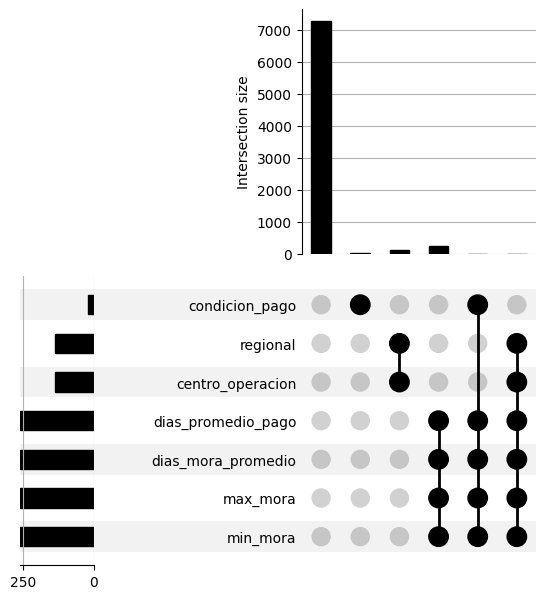

In [ ]:
missing_upsetplot(data_null, element_size = 40)

In [ ]:
# Filtra las entradas que tienen valores nulos
data_null_missing = data_null[data_null.isnull().any(axis=1)]
data_null_missing

,min_mora,max_mora,dias_mora_promedio,dias_promedio_pago,centro_operacion,regional,condicion_pago
4,0.0,76.0,6.0,6.0,NaN,NaN,CTD
9,10.0,564.0,141.0,141.0,NaN,NaN,CTD
13,-31.0,399.0,15.0,22.0,NaN,NaN,CTD
17,-30.0,122.0,4.0,6.0,NaN,NaN,CTD
26,-46.0,43.0,0.0,7.0,NaN,NaN,CTD
32,-47.0,710.0,-24.0,17.0,NaN,NaN,CTD
39,0.0,21.0,10.0,0.0,NaN,NaN,CTD
41,-46.0,15.0,-3.0,4.0,NaN,NaN,CTD
97,NaN,NaN,NaN,NaN,BUENAVENTURA,DS,CTD
147,-5.0,56.0,9.0,9.0,NaN,NaN,CTD


# Imputación de valores nulos

Comparemos que pasaria si eliminamos los datos nulos:

In [ ]:
print(data.shape)
data_dr= data.dropna()
print(data_dr.shape)

(7690, 37)
(7275, 37)


Veamos los porcentajes de datos nulos

In [ ]:
print("Porcentaje de datos nulos de cada atributo\n" + "-"*50)
((data.isnull().sum() / len(data)) * 100).sort_values(ascending=False)

Porcentaje de datos nulos de cada atributo
--------------------------------------------------


,0
min_mora,3.407022
max_mora,3.407022
dias_mora_promedio,3.407022
dias_promedio_pago,3.407022
centro_operacion,1.781534
regional,1.781534
condicion_pago,0.273082
porcentaje_h_pago_a_tiempo,0.000000
saldo_final,0.000000
con_saldos_a_favor,0.000000


Acá veremos si alguna de las columnas tiene mas de 60% de valores nulos

In [ ]:
# guardar los nombres de las columnas
variables = data.columns
variables, len(data.columns)

(Index(['centro_operacion', 'regional', 'unidad_negocio', 'condicion_pago', 'cupo_credito', 'max_prestamo', 'min_prestamo', 'max_pago', 'total_prestamos', 'total_pagado', 'debe', 'promedio_prestamos', 'promedio_pagado', 'promedio_debe', 'dias_promedio_pago', 'dias_mora_promedio', 'max_mora', 'min_mora', 'antiguedad', 'corriente', 'de_1_30', 'de_30_60', 'de_60_90', 'mayor_90', 'saldo_final', 'con_saldos_a_favor', 'sin_saldos_a_favor', 'porcentaje_h_pago_a_tiempo', 'porcentaje_h_1_30', 'porcentaje_h_30_60', 'porcentaje_h_60_90', 'porcentaje_h_mayor_90', 'porcentaje_total_h', 'mora_de_1_30', 'mora_de_30_60', 'mora_de_60_90', 'mora_mayor_90'], dtype='object'),
 37)

In [ ]:
# saving missing values in a variable
a = ((data.isnull().sum())/len(data)*100).sort_values(ascending=False)

# variable para almacenar variables que tienen valores faltantes inferiores a un umbral
variable = [ ]
for i in range(variables.shape[0]):
    if a[i] <= 60: # setting the threshold as 60%
        variable.append(variables[i])

len(data[variable].columns)

37

In [ ]:
# Suponiendo que 'data' es tu DataFrame y 'variables' es una lista de nombres de columnas
variables_numericas = data[variables].select_dtypes(include=['number']).columns
variables_no_numericas = data[variables].select_dtypes(exclude=['number']).columns

# Reemplazar valores nulos por la mediana en variables numéricas
data[variables_numericas] = data[variables_numericas].apply(lambda x: x.fillna(x.median()))

# Reemplazar valores nulos por la moda en variables no numéricas
data[variables_no_numericas] = data[variables_no_numericas].apply(lambda x: x.fillna(x.mode()[0]))

In [ ]:
print("Porcentaje de datos nulos de cada atributo\n" + "-"*50)
((data.isnull().sum() / len(data)) * 100).sort_values(ascending=False)

Porcentaje de datos nulos de cada atributo
--------------------------------------------------


,0
centro_operacion,0.0
corriente,0.0
de_30_60,0.0
de_60_90,0.0
mayor_90,0.0
saldo_final,0.0
con_saldos_a_favor,0.0
sin_saldos_a_favor,0.0
porcentaje_h_pago_a_tiempo,0.0
porcentaje_h_1_30,0.0


In [ ]:
data.head()

,centro_operacion,regional,unidad_negocio,condicion_pago,cupo_credito,max_prestamo,min_prestamo,max_pago,total_prestamos,total_pagado,debe,promedio_prestamos,promedio_pagado,promedio_debe,dias_promedio_pago,dias_mora_promedio,max_mora,min_mora,antiguedad,corriente,de_1_30,de_30_60,de_60_90,mayor_90,saldo_final,con_saldos_a_favor,sin_saldos_a_favor,porcentaje_h_pago_a_tiempo,porcentaje_h_1_30,porcentaje_h_30_60,porcentaje_h_60_90,porcentaje_h_mayor_90,porcentaje_total_h,mora_de_1_30,mora_de_30_60,mora_de_60_90,mora_mayor_90
0,BUCARAMANGA,DN,CIL,08D,4000000.0,17716522.91,500.00,10306826.0,3.966420e+09,3.962965e+09,3455304.26,2.813064e+06,2.810613e+06,2450.5703,7.0,2.0,80.0,-9.0,4409,9101568.0,-5646263.74,0.0,0.0,0.0,-5646263.74,3455304.26,9101568.0,73.43,26.51,0.00,0.05,0.0,100.0,0,0,0,0
1,BUCARAMANGA,DN,CIL,08D,4000000.0,10845178.00,142000.00,8631468.0,7.360998e+07,7.360998e+07,0.00,2.103142e+06,2.103142e+06,0.0000,5.0,1.0,6.0,-3.0,2703,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,29.73,70.26,0.00,0.00,0.0,100.0,0,0,0,0
2,BUCARAMANGA,DN,ADM,15D,240000.0,22000000.00,3089879.49,815375.0,6.187091e+07,5.924490e+07,2626005.00,4.296591e+05,4.114229e+05,18236.1458,452.0,-2.0,25.0,-130.0,2356,2626005.0,0.00,0.0,0.0,0.0,0.00,2626005.00,2626005.0,64.99,35.00,0.00,0.00,0.0,100.0,0,0,0,0
3,YUMBO,DS,GRN,05D,900000.0,977816.42,5500.00,877829.6,3.988233e+07,3.928075e+07,601583.40,2.911119e+05,2.867208e+05,4391.1197,5.0,9.0,56.0,-6.0,2667,0.0,601583.40,0.0,0.0,0.0,601583.40,601583.40,601583.4,14.24,84.27,1.47,0.00,0.0,100.0,1,0,0,0
4,SIBERIA,DC,ADM,CTD,0.0,1100000.00,187.20,1100000.0,4.362371e+07,4.351851e+07,105200.00,3.806606e+04,3.797426e+04,91.7975,6.0,6.0,76.0,0.0,2269,0.0,55000.00,50200.0,0.0,0.0,105200.00,105200.00,105200.0,49.03,49.72,1.21,0.01,0.0,100.0,1,1,0,0


# Variable objetivo

Se crea la variable correspondiente al Churn: determinará si un cliente está en mora o no, bajo el siguiente criterio:

$$\text{Si days}>\#, $$

entonces el cliente tiene obligaciones de pago. **Vamos a ver cuál es el día efectivo.**

Con esto calcula los déciles para días de mora promedio.

In [ ]:
data["dias_mora_promedio"].quantile([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

,dias_mora_promedio
0.0,-772.0
0.1,-3.0
0.2,1.0
0.3,5.0
0.4,9.0
0.5,12.0
0.6,16.0
0.7,23.0
0.8,40.0
0.9,91.0


En este paquete de datos podemos ver que superior a 30 días estará entre un 70% y 80% de los datos, aunque esto varía directamente con el conjunto de datos que tengamos.

In [ ]:
data["good-bad"] = np.where(data["dias_mora_promedio"] > 30,'0','1')
data["good-bad"] = data["good-bad"].astype('category')

Aquí se definió los que son buena paga o mala paga.

In [ ]:
data["good-bad"].value_counts()

,count
good-bad,
1,5798
0,1892


Vamos a ver el resumen descriptivo de nuestro dataset

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cupo_credito,7690.0,1.117039e+07,9.271809e+07,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+06,3.000000e+09
max_prestamo,7690.0,6.727973e+07,2.030056e+09,7.000000e-02,5.956757e+05,2.007885e+06,8.373854e+06,1.278403e+11
min_prestamo,7690.0,1.592140e+06,1.201732e+07,0.000000e+00,1.034625e+04,9.810543e+04,5.706496e+05,4.373191e+08
max_pago,7690.0,3.208353e+07,1.284776e+09,0.000000e+00,4.639556e+05,1.477208e+06,4.990741e+06,9.501787e+10
total_prestamos,7690.0,3.390797e+08,5.370540e+09,0.000000e+00,1.335093e+06,1.220095e+07,7.887319e+07,4.306179e+11
total_pagado,7690.0,3.492019e+08,6.362536e+09,0.000000e+00,1.234557e+06,1.177449e+07,7.604805e+07,5.208804e+11
debe,7690.0,-1.012222e+07,1.044081e+09,-9.026248e+10,0.000000e+00,0.000000e+00,2.312353e+05,2.064786e+09
promedio_prestamos,7690.0,3.134144e+06,1.767911e+07,0.000000e+00,2.272816e+05,6.436809e+05,1.881945e+06,5.032796e+08
promedio_pagado,7690.0,3.031529e+06,1.714048e+07,0.000000e+00,2.099981e+05,6.112387e+05,1.807029e+06,5.032796e+08
promedio_debe,7690.0,1.026144e+05,2.123164e+06,-2.291408e+07,0.000000e+00,0.000000e+00,3.414340e+03,1.720655e+08


# Analisis univariado

### Variables categóricas

In [ ]:
data['mora_de_1_30'] = data['mora_de_1_30'].astype('category')
data['mora_de_30_60'] = data['mora_de_30_60'].astype('category')
data['mora_de_60_90'] = data['mora_de_60_90'].astype('category')
data['mora_mayor_90'] = data['mora_mayor_90'].astype('category')

In [ ]:
categorical_feat = list(data.select_dtypes(include=['category','object']).columns)

In [ ]:
data[categorical_feat] = data[categorical_feat].applymap(str)

Ahora veremos cuantas opciones se tienen en esas variables

In [ ]:
data[categorical_feat].nunique().reset_index().sort_values(by=0, ascending=False)

,index,0
0,centro_operacion,27
3,condicion_pago,16
2,unidad_negocio,7
1,regional,4
4,mora_de_1_30,2
5,mora_de_30_60,2
6,mora_de_60_90,2
7,mora_mayor_90,2
8,good-bad,2


Vamos a disminuir la cantidad de opciones en estas variables categoricas, usando una conversión por frecuencia y observando su distribución por cuartiles.

In [ ]:
temp_co = data['centro_operacion'].value_counts()
temp_cp = data['condicion_pago'].value_counts()
temp_un = data['unidad_negocio'].value_counts()

In [ ]:
centro_operacion_count = data['centro_operacion'].apply(lambda x: temp_co[x])
condicion_pago_count = data['condicion_pago'].apply(lambda x: temp_cp[x])
unidad_negocio_count = data['unidad_negocio'].apply(lambda x: temp_un[x])

A cada valor le va a correponder la frecuencia del mismo, la distribución sería así:

Comenzamos con centro de operación (tiene 27 opciones):

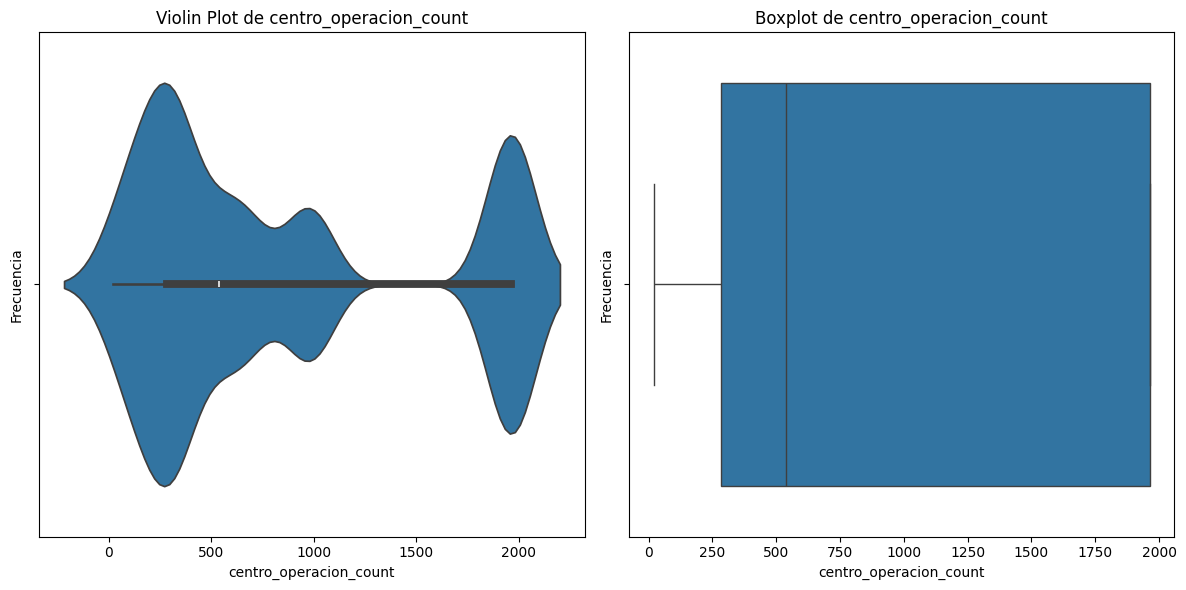

In [ ]:
# 'centro_operacion_count' es la variable que deseas visualizar
plt.figure(figsize=(12, 6))

# Violin Plot
plt.subplot(1, 2, 1)
sns.violinplot(x=centro_operacion_count)
plt.title('Violin Plot de centro_operacion_count')
plt.xlabel('centro_operacion_count')
plt.ylabel('Frecuencia')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=centro_operacion_count)
plt.title('Boxplot de centro_operacion_count')
plt.xlabel('centro_operacion_count')
plt.ylabel('Frecuencia')

# Ajusta el diseño para evitar solapamiento
plt.tight_layout()

# Muestra los gráficos
plt.show()

In [ ]:
centro_operacion_count.quantile([0,0.1,.2,.3,.4,.5,.6,.7,.8,.9])

,centro_operacion
0.0,20.0
0.1,109.0
0.2,224.0
0.3,318.0
0.4,339.0
0.5,538.0
0.6,673.0
0.7,979.0
0.8,1963.0
0.9,1963.0


Vamos a llamar 'Otro centro' a aquellos por debajo de 0.2

In [ ]:
for i in range(0, len(data)):
    if centro_operacion_count[i] < centro_operacion_count.quantile(0.2):
        data['centro_operacion'][i] = 'OTRO CENTRO'

In [ ]:
data['centro_operacion'].value_counts()

,count
centro_operacion,
SIBERIA,1963
OTRO CENTRO,1427
YUMBO,979
OFICINA CENTRAL,673
BELLO,538
CHIQUINQUIRA,364
MANIZALES,339
BUCARAMANGA,320
CARTAGENA,318


Similar para condición de pago y unidad de negocio

In [ ]:
condicion_pago_count.quantile([0,0.1,.2,.3,.4,.5,.6,.7,.8,.9])

,condicion_pago
0.0,1.0
0.1,307.0
0.2,692.0
0.3,2071.0
0.4,2071.0
0.5,2071.0
0.6,3608.0
0.7,3608.0
0.8,3608.0
0.9,3608.0


In [ ]:
for i in range(0, len(data)):
    if condicion_pago_count[i] < condicion_pago_count.quantile(0.1):
        data['condicion_pago'][i] = 'OTRA CONDICION'

In [ ]:
data['condicion_pago'].value_counts()

,count
condicion_pago,
CTD,3608
30D,2071
08D,692
OTRA CONDICION,682
15D,330
60D,307


In [ ]:
unidad_negocio_count.quantile([0,0.1,.2,.3,.4,.5,.6,.7,.8,.9])

,unidad_negocio
0.0,1.0
0.1,1726.0
0.2,1726.0
0.3,2316.0
0.4,2316.0
0.5,2316.0
0.6,3343.0
0.7,3343.0
0.8,3343.0
0.9,3343.0


In [ ]:
for i in range(0, len(data)):
    if unidad_negocio_count[i] < unidad_negocio_count.quantile(0.1):
        data['unidad_negocio'][i] = 'OTRO NEGOCIO'

In [ ]:
data['unidad_negocio'].value_counts()

,count
unidad_negocio,
GRN,3343
CIL,2316
ADM,1726
OTRO NEGOCIO,305


### Inferencia en categóricas

In [ ]:
# Listing the Numerical and Categorical datatypes
numerical_feat = list(data.select_dtypes(include=['int64','float64','Int64']).columns)
categorical_feat = list(data.select_dtypes(include=['category','object']).columns)

In [ ]:
data[categorical_feat].describe().T

,count,unique,top,freq
centro_operacion,7690,12,SIBERIA,1963
regional,7690,4,DC,3321
unidad_negocio,7690,4,GRN,3343
condicion_pago,7690,6,CTD,3608
mora_de_1_30,7690,2,0,6735
mora_de_30_60,7690,2,0,7307
mora_de_60_90,7690,2,0,7480
mora_mayor_90,7690,2,0,7275
good-bad,7690,2,1,5798


Ahora la variable good-bad tiene la siguiente caracteristica

In [ ]:
target_group = data.groupby('good-bad').size().reset_index()
target_group.columns = ['good-bad','total']
target_group['%'] = round(target_group['total']*100/sum(target_group['total']),2)
target_group.sort_values(by='total', ascending=False)

,good-bad,total,%
1,1,5798,75.4
0,0,1892,24.6


In [ ]:
y = data['good-bad'].astype(int)
X = data.drop(['good-bad'],axis=1)

In [ ]:
#Let’s split X and y using Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state= 1727, stratify=y)

#get shape of train and test data
print("train data size:", X_train.shape)
print("test data size:", X_test.shape)
print("test data size:", y_test.shape)

train data size: (6152, 37)
test data size: (1538, 37)
test data size: (1538,)


In [ ]:
#grouping X_train by values
X_train_cat = X_train.select_dtypes(include=['object', 'category']).copy()
X_train_num = X_train.select_dtypes(include = 'number').copy()

In [ ]:
X_train_cat

,centro_operacion,regional,unidad_negocio,condicion_pago,mora_de_1_30,mora_de_30_60,mora_de_60_90,mora_mayor_90
2289,OTRO CENTRO,DC,ADM,15D,0,0,0,0
3218,SIBERIA,DC,GRN,60D,0,0,0,0
2027,OFICINA CENTRAL,OC,ADM,CTD,0,0,0,0
4081,SIBERIA,DC,ADM,30D,0,0,0,0
2378,OTRO CENTRO,DC,ADM,CTD,0,0,0,1
...,...,...,...,...,...,...,...,...
5155,MANIZALES,DS,CIL,CTD,0,0,0,0
6300,YUMBO,DS,GRN,OTRA CONDICION,0,0,0,0
3656,CHIQUINQUIRA,DC,CIL,08D,1,0,0,0
3148,SIBERIA,DC,GRN,60D,0,0,1,0


Con esto queda dividido el dataset en prueba y entrenamiento.

Aquí usamos la distribución Chi cuadrado, realizamos una prueba de chi-cuadrado para evaluar la independencia entre cada variable categórica en X_train_cat y la variable objetivo y_train

In [ ]:
# define an empty dictionary to store chi-squared test results
chi2_check = {}

# loop over each column in the training set to calculate chi-statistic with the target variable
for column in X_train_cat:
    chi, p, dof, ex = chi2_contingency(pd.crosstab(y_train, X_train_cat[column]))
    chi2_check.setdefault('Feature',[]).append(column)
    chi2_check.setdefault('p-value',[]).append(round(p, 10))

# convert the dictionary to a DF
chi2_result = pd.DataFrame(data = chi2_check)
# chi2_result.sort_values(by = ['p-value'], ascending = True, ignore_index = True, inplace = True)
data_merge = chi2_result.merge(X_train_cat.describe().T.reset_index(),
                  left_on='Feature',
                  right_on='index').sort_values(by=['p-value', 'unique'])

In [ ]:
data_merge

,Feature,p-value,index,count,unique,top,freq
5,mora_de_30_60,0.000000,mora_de_30_60,6152,2,0,5840
6,mora_de_60_90,0.000000,mora_de_60_90,6152,2,0,5972
7,mora_mayor_90,0.000000,mora_mayor_90,6152,2,0,5811
1,regional,0.000000,regional,6152,4,DC,2640
2,unidad_negocio,0.000000,unidad_negocio,6152,4,GRN,2681
3,condicion_pago,0.000000,condicion_pago,6152,6,CTD,2882
0,centro_operacion,0.000000,centro_operacion,6152,12,SIBERIA,1546
4,mora_de_1_30,0.000153,mora_de_1_30,6152,2,0,5376


In [ ]:
#p_data = data_merge[(data_merge['p-value']<0.05) & (data_merge['unique']<data_merge['unique'].median())].sort_values(by='p-value')
p_data = data_merge[(data_merge['p-value']<0.05)].sort_values(by='p-value')
p_data

,Feature,p-value,index,count,unique,top,freq
5,mora_de_30_60,0.000000,mora_de_30_60,6152,2,0,5840
6,mora_de_60_90,0.000000,mora_de_60_90,6152,2,0,5972
7,mora_mayor_90,0.000000,mora_mayor_90,6152,2,0,5811
1,regional,0.000000,regional,6152,4,DC,2640
2,unidad_negocio,0.000000,unidad_negocio,6152,4,GRN,2681
3,condicion_pago,0.000000,condicion_pago,6152,6,CTD,2882
0,centro_operacion,0.000000,centro_operacion,6152,12,SIBERIA,1546
4,mora_de_1_30,0.000153,mora_de_1_30,6152,2,0,5376


In [ ]:
X_train[list(p_data['Feature'])].sample(5)

,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30
28,0,0,0,DS,GRN,CTD,BELLO,0
2117,1,1,1,OC,OTRO NEGOCIO,30D,OFICINA CENTRAL,0
2309,0,0,0,DC,CIL,15D,SIBERIA,0
5701,0,0,0,DC,ADM,08D,SIBERIA,0
2152,0,0,1,OC,OTRO NEGOCIO,30D,OFICINA CENTRAL,0


### Inferencia numérica

In [ ]:
f_statistics, p_values = f_classif(X_train_num.fillna(X_train_num.median()), y_train)

In [ ]:
# convert to a df
anova_f_table = pd.DataFrame(data={'Feature': X_train_num.columns.values,
                                   'F-Score': f_statistics,
                                   'p-value': p_values.round(decimals=10)})
anova_merge = anova_f_table.merge(X_train_num.describe().T.reset_index(),
                    left_on='Feature',
                    right_on='index').sort_values(['F-Score', 'count'], ascending=False).head(50)

In [ ]:
anova_merge

,Feature,F-Score,p-value,index,count,mean,std,min,25%,50%,75%,max
27,porcentaje_h_mayor_90,3361.242963,0.000000,porcentaje_h_mayor_90,6152.0,8.606074e+00,2.275846e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.702500e+00,1.000000e+02
11,dias_mora_promedio,2621.781045,0.000000,dias_mora_promedio,6152.0,3.613719e+01,1.014785e+02,-7.720000e+02,3.000000e+00,1.200000e+01,3.000000e+01,1.456000e+03
10,dias_promedio_pago,1753.168058,0.000000,dias_promedio_pago,6152.0,6.094620e+01,1.068859e+02,0.000000e+00,1.000000e+01,3.300000e+01,6.200000e+01,1.456000e+03
12,max_mora,1379.726952,0.000000,max_mora,6152.0,1.576037e+02,2.511578e+02,-3.640000e+02,2.600000e+01,6.700000e+01,1.840000e+02,6.209000e+03
26,porcentaje_h_60_90,754.116434,0.000000,porcentaje_h_60_90,6152.0,3.267295e+00,1.155151e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e-01,1.000000e+02
23,porcentaje_h_pago_a_tiempo,731.202834,0.000000,porcentaje_h_pago_a_tiempo,6152.0,3.307978e+01,3.515762e+01,0.000000e+00,0.000000e+00,2.033000e+01,5.634250e+01,1.000000e+02
25,porcentaje_h_30_60,719.602052,0.000000,porcentaje_h_30_60,6152.0,8.626694e+00,1.813096e+01,0.000000e+00,0.000000e+00,0.000000e+00,8.690000e+00,1.000000e+02
24,porcentaje_h_1_30,503.730061,0.000000,porcentaje_h_1_30,6152.0,4.286484e+01,3.577615e+01,0.000000e+00,2.422500e+00,4.078500e+01,7.500000e+01,1.000000e+02
13,min_mora,112.564468,0.000000,min_mora,6152.0,-1.178560e+01,2.629893e+02,-1.820200e+04,-2.200000e+01,-4.000000e+00,1.000000e+00,1.456000e+03
14,antiguedad,5.479178,0.019276,antiguedad,6152.0,2.039561e+03,1.847995e+03,1.100000e+01,8.230000e+02,1.909000e+03,2.684000e+03,2.424600e+04


In [ ]:
# selected categorical features by low cardinality and lowest p-value
p_anova = anova_merge[(anova_merge['p-value']<0.05)].sort_values(by='p-value')
p_anova

,Feature,F-Score,p-value,index,count,mean,std,min,25%,50%,75%,max
27,porcentaje_h_mayor_90,3361.242963,0.000000,porcentaje_h_mayor_90,6152.0,8.606074,2.275846e+01,0.000000e+00,0.0000,0.000,1.7025,1.000000e+02
11,dias_mora_promedio,2621.781045,0.000000,dias_mora_promedio,6152.0,36.137191,1.014785e+02,-7.720000e+02,3.0000,12.000,30.0000,1.456000e+03
10,dias_promedio_pago,1753.168058,0.000000,dias_promedio_pago,6152.0,60.946196,1.068859e+02,0.000000e+00,10.0000,33.000,62.0000,1.456000e+03
12,max_mora,1379.726952,0.000000,max_mora,6152.0,157.603706,2.511578e+02,-3.640000e+02,26.0000,67.000,184.0000,6.209000e+03
26,porcentaje_h_60_90,754.116434,0.000000,porcentaje_h_60_90,6152.0,3.267295,1.155151e+01,0.000000e+00,0.0000,0.000,0.2200,1.000000e+02
23,porcentaje_h_pago_a_tiempo,731.202834,0.000000,porcentaje_h_pago_a_tiempo,6152.0,33.079776,3.515762e+01,0.000000e+00,0.0000,20.330,56.3425,1.000000e+02
25,porcentaje_h_30_60,719.602052,0.000000,porcentaje_h_30_60,6152.0,8.626694,1.813096e+01,0.000000e+00,0.0000,0.000,8.6900,1.000000e+02
24,porcentaje_h_1_30,503.730061,0.000000,porcentaje_h_1_30,6152.0,42.864836,3.577615e+01,0.000000e+00,2.4225,40.785,75.0000,1.000000e+02
13,min_mora,112.564468,0.000000,min_mora,6152.0,-11.785598,2.629893e+02,-1.820200e+04,-22.0000,-4.000,1.0000,1.456000e+03
14,antiguedad,5.479178,0.019276,antiguedad,6152.0,2039.561443,1.847995e+03,1.100000e+01,823.0000,1909.000,2684.0000,2.424600e+04


In [ ]:
list(p_anova['Feature'])

['porcentaje_h_mayor_90',
 'dias_mora_promedio',
 'dias_promedio_pago',
 'max_mora',
 'porcentaje_h_60_90',
 'porcentaje_h_pago_a_tiempo',
 'porcentaje_h_30_60',
 'porcentaje_h_1_30',
 'min_mora',
 'antiguedad',
 'de_30_60']

In [ ]:
X_train[list(p_anova['Feature'])].sample(5)

,porcentaje_h_mayor_90,dias_mora_promedio,dias_promedio_pago,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,de_30_60
6368,0.00,7.0,50.0,111.0,0.00,44.55,2.95,52.48,-17.0,3647,0.0
4115,37.27,69.0,74.0,517.0,1.73,3.27,0.00,57.70,-2.0,2901,0.0
7121,30.46,200.0,200.0,795.0,0.00,0.00,0.00,69.53,1.0,3208,0.0
536,0.00,6.0,21.0,25.0,0.00,1.62,0.00,98.37,0.0,2389,0.0
2737,0.00,-42.0,1.0,1.0,0.00,97.73,0.00,2.26,-46.0,2586,0.0


### Correlación

In [ ]:
# creating the correlation matrix
corr_matrix = X_train[list(p_anova['Feature'])].corr().abs()

In [ ]:
corr_matrix

,porcentaje_h_mayor_90,dias_mora_promedio,dias_promedio_pago,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,de_30_60
porcentaje_h_mayor_90,1.000000,0.719500,0.653666,0.378451,0.027794,0.261426,0.063893,0.318342,0.204610,0.003736,0.012036
dias_mora_promedio,0.719500,1.000000,0.824922,0.503225,0.073007,0.278052,0.016799,0.193311,0.329319,0.014739,0.002571
dias_promedio_pago,0.653666,0.824922,1.000000,0.448877,0.066228,0.233875,0.017718,0.190738,0.171955,0.000763,0.007617
max_mora,0.378451,0.503225,0.448877,1.000000,0.035846,0.113497,0.001766,0.104610,0.090734,0.128436,0.146898
porcentaje_h_60_90,0.027794,0.073007,0.066228,0.035846,1.000000,0.172904,0.065256,0.175726,0.021591,0.026733,0.020098
porcentaje_h_pago_a_tiempo,0.261426,0.278052,0.233875,0.113497,0.172904,1.000000,0.257786,0.536714,0.114185,0.120628,0.021613
porcentaje_h_30_60,0.063893,0.016799,0.017718,0.001766,0.065256,0.257786,1.000000,0.186784,0.014882,0.060251,0.019692
porcentaje_h_1_30,0.318342,0.193311,0.190738,0.104610,0.175726,0.536714,0.186784,1.000000,0.035280,0.012364,0.002632
min_mora,0.204610,0.329319,0.171955,0.090734,0.021591,0.114185,0.014882,0.035280,1.000000,0.014157,0.794709
antiguedad,0.003736,0.014739,0.000763,0.128436,0.026733,0.120628,0.060251,0.012364,0.014157,1.000000,0.000693


In [ ]:
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [ ]:
c = X_train[list(p_anova['Feature'])].corr().abs()
s = c.unstack()
so = s.sort_values(kind="quicksort",ascending = False)
so = pd.DataFrame(so, columns=['Pearson Correlation'])

In [ ]:
so[so['Pearson Correlation']<1].head()

,,Pearson Correlation
dias_mora_promedio,dias_promedio_pago,0.824922
dias_promedio_pago,dias_mora_promedio,0.824922
de_30_60,min_mora,0.794709
min_mora,de_30_60,0.794709
porcentaje_h_mayor_90,dias_mora_promedio,0.719500


In [ ]:
so_cond = so[(so['Pearson Correlation'] < 1)|(so['Pearson Correlation'] == 1)]

In [ ]:
so[so['Pearson Correlation']<1].describe().T

,count,mean,std,min,25%,50%,75%,max
Pearson Correlation,110.0,0.169339,0.21029,0.000693,0.018211,0.090734,0.226559,0.824922


In [ ]:
# fining index of variables with correlation greater than the threshold
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
to_drop

['dias_mora_promedio', 'dias_promedio_pago', 'de_30_60']

In [ ]:
num_consider = [x for x in list(p_anova['Feature']) if x not in to_drop]
list(p_anova['Feature'])

['porcentaje_h_mayor_90',
 'dias_mora_promedio',
 'dias_promedio_pago',
 'max_mora',
 'porcentaje_h_60_90',
 'porcentaje_h_pago_a_tiempo',
 'porcentaje_h_30_60',
 'porcentaje_h_1_30',
 'min_mora',
 'antiguedad',
 'de_30_60']

Las variables para entrenar serán las siguientes:

In [ ]:
selected_cols = num_consider + list(p_data['Feature'])
selected_cols

['porcentaje_h_mayor_90',
 'max_mora',
 'porcentaje_h_60_90',
 'porcentaje_h_pago_a_tiempo',
 'porcentaje_h_30_60',
 'porcentaje_h_1_30',
 'min_mora',
 'antiguedad',
 'mora_de_30_60',
 'mora_de_60_90',
 'mora_mayor_90',
 'regional',
 'unidad_negocio',
 'condicion_pago',
 'centro_operacion',
 'mora_de_1_30']

Aplicando la selección de variables, sería así:

In [ ]:
# apply feature selection to X_train and X_test
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
porcentaje_h_mayor_90,6152.0,8.606074,22.758458,0.0,0.0000,0.000,1.7025,100.0
max_mora,6152.0,157.603706,251.157834,-364.0,26.0000,67.000,184.0000,6209.0
porcentaje_h_60_90,6152.0,3.267295,11.551513,0.0,0.0000,0.000,0.2200,100.0
porcentaje_h_pago_a_tiempo,6152.0,33.079776,35.157616,0.0,0.0000,20.330,56.3425,100.0
porcentaje_h_30_60,6152.0,8.626694,18.130961,0.0,0.0000,0.000,8.6900,100.0
porcentaje_h_1_30,6152.0,42.864836,35.776145,0.0,2.4225,40.785,75.0000,100.0
min_mora,6152.0,-11.785598,262.989302,-18202.0,-22.0000,-4.000,1.0000,1456.0
antiguedad,6152.0,2039.561443,1847.994933,11.0,823.0000,1909.000,2684.0000,24246.0


### Peso de la evidencia y Valor de la información

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

**Peso de la Evidencia (WoE):**

El WoE mide la fuerza de la relación entre una variable predictora y la variable objetivo, especialmente en el contexto de clasificación binaria (como riesgo de crédito positivo o negativo).


Un WoE positivo sugiere que la categoría está asociada con un mayor riesgo de eventos positivos, mientras que un WoE negativo sugiere lo contrario. Un WoE cercano a cero indica que la categoría tiene poco impacto en el riesgo.


**Valor de la Información (IV):**

El IV resume la importancia predictiva global de una variable, considerando todos los niveles de una variable categórica.


Un IV alto indica una mayor capacidad predictiva de la variable, mientras que un IV bajo sugiere que la variable puede no ser informativa.

Ver [Weight of Evidence (WoE) and Information Value (IV)](https://anikch.medium.com/weight-of-evidence-woe-and-information-value-iv-how-to-use-it-in-eda-and-model-building-3b3b98efe0e8)


In [ ]:
def dummy_creation(df, cols):
    df_dummies = pd.get_dummies(df[cols], prefix_sep=':')
    df_dummies = df_dummies.astype(int) # esto para que sean 0s y 1s
    df = pd.concat([df, df_dummies], axis=1)
    return df

In [ ]:
X_train.shape, X_test.shape

((6152, 16), (1538, 16))

In [ ]:
X_train.columns

Index(['porcentaje_h_mayor_90', 'max_mora', 'porcentaje_h_60_90', 'porcentaje_h_pago_a_tiempo', 'porcentaje_h_30_60', 'porcentaje_h_1_30', 'min_mora', 'antiguedad', 'mora_de_30_60', 'mora_de_60_90', 'mora_mayor_90', 'regional', 'unidad_negocio', 'condicion_pago', 'centro_operacion', 'mora_de_1_30'], dtype='object')

In [ ]:
X_train.sample(2)

,porcentaje_h_mayor_90,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30
6493,1.4,167.0,1.67,2.49,4.09,90.32,-28.0,2279,0,0,0,DC,GRN,30D,SIBERIA,1
7684,0.0,37.0,0.00,34.95,0.05,64.99,-44.0,2520,0,0,0,DS,CIL,CTD,MANIZALES,0


In [ ]:
X_train = dummy_creation(X_train, list(p_data['Feature']))
X_test = dummy_creation(X_test, list(p_data['Feature']))

X_test = X_test.reindex(labels=X_train.columns, axis=1, fill_value=0)
y_test = y_test.reindex(axis=1, fill_value=0)

In [ ]:
list(p_data['Feature'])

['mora_de_30_60',
 'mora_de_60_90',
 'mora_mayor_90',
 'regional',
 'unidad_negocio',
 'condicion_pago',
 'centro_operacion',
 'mora_de_1_30']

In [ ]:
X_train.sample(2)

,porcentaje_h_mayor_90,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30,mora_de_30_60:0,mora_de_30_60:1,mora_de_60_90:0,mora_de_60_90:1,mora_mayor_90:0,mora_mayor_90:1,regional:DC,regional:DN,regional:DS,regional:OC,unidad_negocio:ADM,unidad_negocio:CIL,unidad_negocio:GRN,unidad_negocio:OTRO NEGOCIO,condicion_pago:08D,condicion_pago:15D,condicion_pago:30D,condicion_pago:60D,condicion_pago:CTD,condicion_pago:OTRA CONDICION,centro_operacion:BELLO,centro_operacion:BUCARAMANGA,centro_operacion:CARTAGENA,centro_operacion:CHIQUINQUIRA,centro_operacion:CUCUTA,centro_operacion:MANIZALES,centro_operacion:OFICINA CENTRAL,centro_operacion:OTRO CENTRO,centro_operacion:PITALITO,centro_operacion:SIBERIA,centro_operacion:VILLANUEVA,centro_operacion:YUMBO,mora_de_1_30:0,mora_de_1_30:1
5774,0.0,1.0,0.00,82.64,0.00,17.35,-30.0,494,0,0,0,DS,CIL,CTD,MANIZALES,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1301,0.0,88.0,4.36,43.16,9.13,43.33,-21.0,1732,0,0,0,DC,CIL,30D,CHIQUINQUIRA,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Preparar copias para el WoE
X_train_prepr = X_train.copy()
y_train_prepr = y_train.copy()
X_test_prepr = X_test.copy()
y_test_prepr = y_test.copy()

#### "Punto de guardado"

In [ ]:
# Esta parte es usada para hacer cambios de train a test, a partir de acá se automatiza

inputs_prepr = X_train_prepr.copy()
inputs_target = y_train_prepr.copy()

#inputs_prepr = X_test_prepr.copy()
#inputs_target = y_test_prepr.copy()

In [ ]:
X_train_prepr.shape,X_test_prepr.shape,y_train_prepr.shape, y_test_prepr.shape

((6152, 50), (1538, 50), (6152,), (1538,))

In [ ]:
inputs_prepr.shape, inputs_target.shape

((6152, 50), (6152,))

In [ ]:
# The function takes 3 arguments: a dataframe (X_train_prepr), a string (column name), and a dataframe (y_train_prepr).
# The function returns a dataframe as a result.
def woe_discrete(df, cat_variable_name, y_df):
    df = pd.concat([df[cat_variable_name], y_df], axis = 1)
    df = df.groupby(cat_variable_name, as_index=False).agg({df.columns[1]: ['count', 'sum']})
    df.columns = [cat_variable_name, 'n_obs', 'n_good']
    df['n_bad'] = df['n_obs'] - df['n_good']

    # WOE
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop=True)

    # Difference between consequtive rows
    df['diff_prop_good'] = (df['n_good'] / df['n_obs']).diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()

    # IV
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [ ]:
# set the default style of the graphs to the seaborn style.
sns.set()

# define a function for plotting WoE across categories that takes 2 arguments: a dataframe and a number.
def plot_by_woe(df_WoE, rotation_of_x_axis_labels=0):
    plt.figure(figsize=(16, 4))
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    y = df_WoE['WoE']
    sns.lineplot(x=x, y=y, marker='o', linestyle='dotted', color='red')
    plt.xlabel(df_WoE.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)
    plt.show()

En la siguiente tabla se puede interpretar el IV (pensando en una regresión logistica):

![Tabla IV](https://miro.medium.com/v2/resize:fit:640/format:webp/1*prl00Y2OtCtdYj6LmTz2eQ.png)

#### Categóricas

In [ ]:
inputs_prepr[list(p_data['Feature'])].nunique().sort_values()

,0
mora_de_30_60,2
mora_de_60_90,2
mora_mayor_90,2
mora_de_1_30,2
regional,4
unidad_negocio,4
condicion_pago,6
centro_operacion,12


##### Centro de operación

In [ ]:
woe_discrete(inputs_prepr, 'centro_operacion', inputs_target)

,centro_operacion,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,SIBERIA,1546,1055,491,0.251300,0.324306,0.227469,-0.354676,NaN,NaN,0.11179
1,CHIQUINQUIRA,297,207,90,0.048277,0.059445,0.044631,-0.286619,0.014563,0.068057,0.11179
2,CUCUTA,230,164,66,0.037386,0.043593,0.035360,-0.209316,0.016074,0.077303,0.11179
3,VILLANUEVA,200,148,52,0.032510,0.034346,0.031910,-0.073560,0.026957,0.135757,0.11179
4,OFICINA CENTRAL,526,392,134,0.085501,0.088507,0.084519,-0.046106,0.005247,0.027453,0.11179
5,YUMBO,796,595,201,0.129389,0.132761,0.128288,-0.034272,0.002240,0.011834,0.11179
6,BELLO,437,330,107,0.071034,0.070674,0.071151,0.006736,0.007661,0.041007,0.11179
7,PITALITO,187,150,37,0.030397,0.024439,0.032342,0.280189,0.046990,0.273454,0.11179
8,CARTAGENA,258,207,51,0.041938,0.033686,0.044631,0.281365,0.000187,0.001176,0.11179
9,OTRO CENTRO,1153,941,212,0.187419,0.140026,0.202889,0.370829,0.013806,0.089464,0.11179


Es un predictor de nivel medio

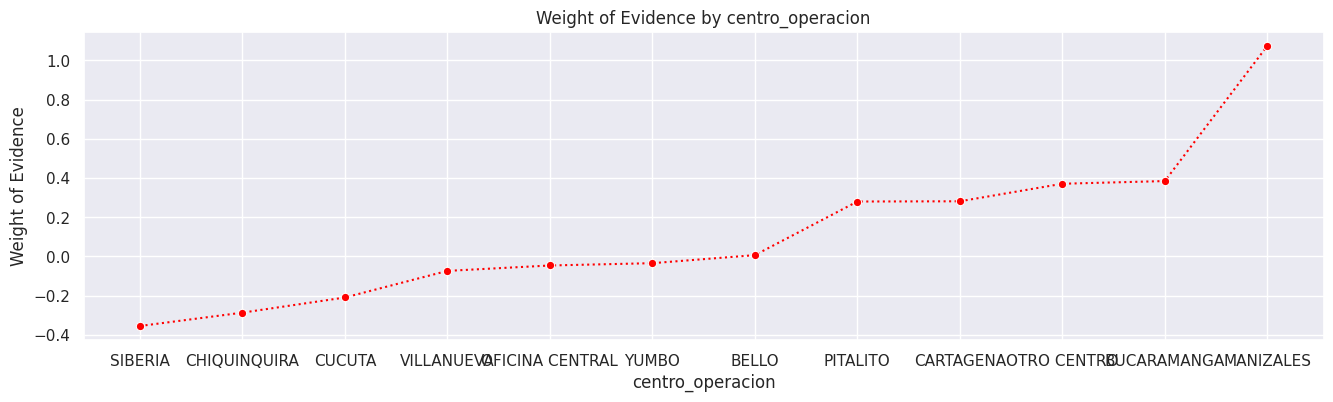

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'centro_operacion', inputs_target))

In [ ]:
mapeo_centros = {
    'VILLANUEVA': 'VILLANUEVA_YUMBO_BELLO',
    'OFICINA CENTRAL': 'VILLANUEVA_YUMBO_BELLO',
    'YUMBO': 'VILLANUEVA_YUMBO_BELLO',
    'BELLO': 'VILLANUEVA_YUMBO_BELLO',
    'PITALITO': 'CARTAGENA_BUCARAMANGA',
    'CARTAGENA': 'CARTAGENA_BUCARAMANGA',
    'OTRO CENTRO': 'CARTAGENA_BUCARAMANGA',
    'BUCARAMANGA': 'CARTAGENA_BUCARAMANGA'
}

# Aplicar el mapeo a la columna 'centro_operacion'
inputs_prepr['centro_operacion'] = inputs_prepr['centro_operacion'].replace(mapeo_centros)
inputs_prepr['centro_operacion'].value_counts()

,count
centro_operacion,
VILLANUEVA_YUMBO_BELLO,1959
CARTAGENA_BUCARAMANGA,1851
SIBERIA,1546
CHIQUINQUIRA,297
MANIZALES,269
CUCUTA,230


In [ ]:
woe_discrete(inputs_prepr, 'centro_operacion', inputs_target)

,centro_operacion,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,SIBERIA,1546,1055,491,0.251300,0.324306,0.227469,-0.354676,NaN,NaN,0.111166
1,CHIQUINQUIRA,297,207,90,0.048277,0.059445,0.044631,-0.286619,0.014563,0.068057,0.111166
2,CUCUTA,230,164,66,0.037386,0.043593,0.035360,-0.209316,0.016074,0.077303,0.111166
3,VILLANUEVA_YUMBO_BELLO,1959,1465,494,0.318433,0.326288,0.315869,-0.032453,0.034787,0.176863,0.111166
4,CARTAGENA_BUCARAMANGA,1851,1505,346,0.300878,0.228534,0.324493,0.350581,0.065243,0.383034,0.111166
5,MANIZALES,269,242,27,0.043726,0.017834,0.052178,1.073573,0.086554,0.722991,0.111166


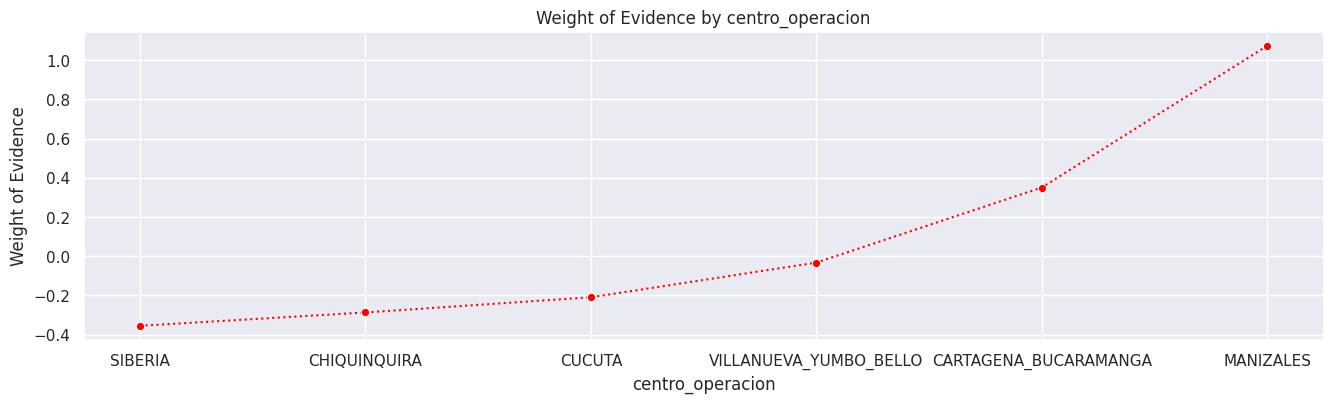

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'centro_operacion', inputs_target))

In [ ]:
inputs_prepr['centro_operacion:VILLANUEVA_YUMBO_BELLO'] = sum([inputs_prepr['centro_operacion:VILLANUEVA'], inputs_prepr['centro_operacion:OFICINA CENTRAL'], inputs_prepr['centro_operacion:YUMBO'], inputs_prepr['centro_operacion:BELLO']])
inputs_prepr['centro_operacion:CARTAGENA_BUCARAMANGA'] = sum([inputs_prepr['centro_operacion:CARTAGENA'], inputs_prepr['centro_operacion:PITALITO'], inputs_prepr['centro_operacion:OTRO CENTRO'], inputs_prepr['centro_operacion:BUCARAMANGA']])

##### mora_de_30_60

In [ ]:
woe_discrete(inputs_prepr, 'mora_de_30_60', inputs_target)

,mora_de_30_60,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,1,312,172,140,0.050715,0.09247,0.037085,-0.913676,NaN,NaN,0.053885
1,0,5840,4466,1374,0.949285,0.90753,0.962915,0.059239,0.213444,0.972915,0.053885


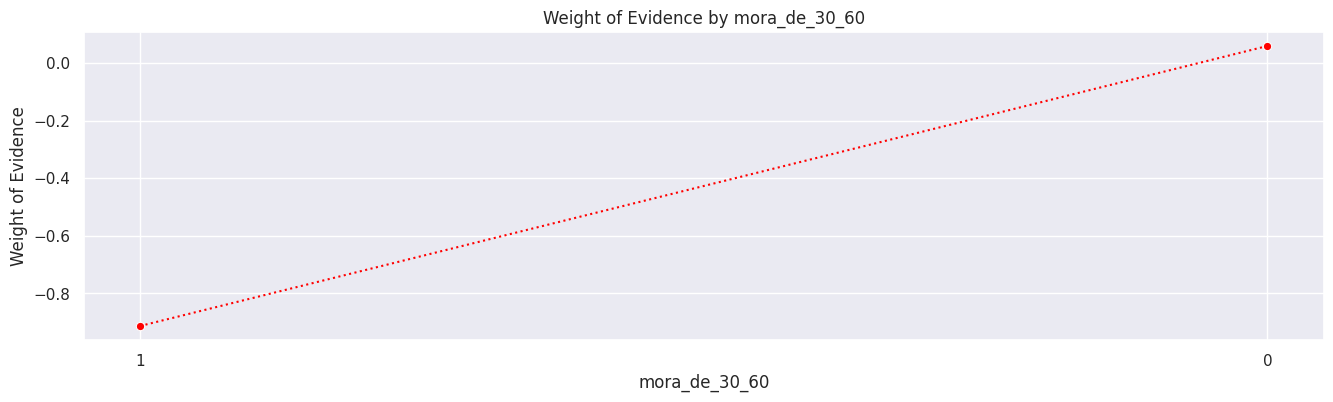

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'mora_de_30_60', inputs_target))

##### mora_de_60_90

In [ ]:
woe_discrete(inputs_prepr, 'mora_de_60_90', inputs_target)

,mora_de_60_90,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,1,180,90,90,0.029259,0.059445,0.019405,-1.119528,NaN,NaN,0.046495
1,0,5972,4548,1424,0.970741,0.940555,0.980595,0.041690,0.261554,1.161218,0.046495


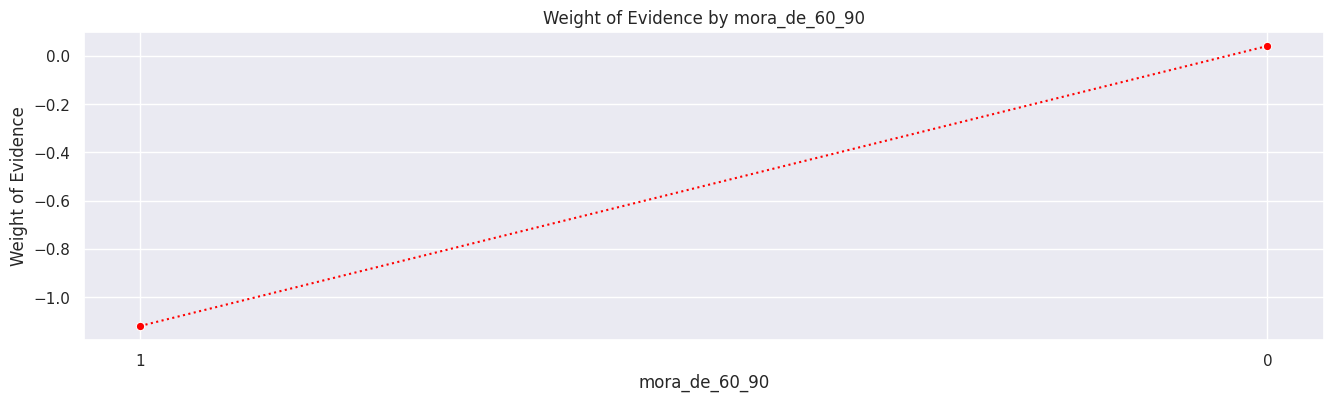

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'mora_de_60_90', inputs_target))

##### mora_mayor_90

In [ ]:
woe_discrete(inputs_prepr, 'mora_mayor_90', inputs_target)

,mora_mayor_90,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,1,341,189,152,0.055429,0.100396,0.04075,-0.901662,NaN,NaN,0.05761
1,0,5811,4449,1362,0.944571,0.899604,0.95925,0.064197,0.211365,0.965859,0.05761


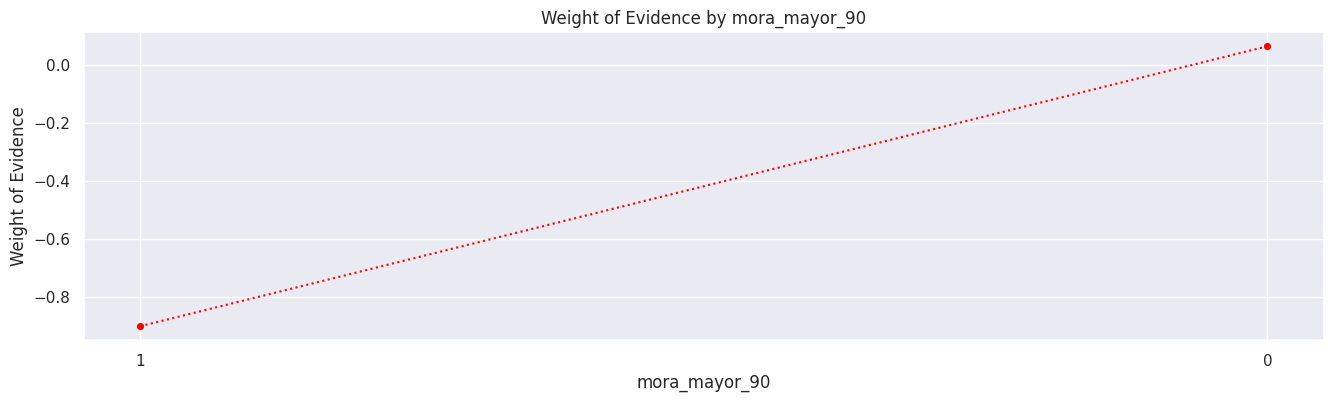

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'mora_mayor_90', inputs_target))

##### mora_de_1_30

In [ ]:
woe_discrete(inputs_prepr, 'mora_de_1_30', inputs_target)

,mora_de_1_30,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,0,5376,4010,1366,0.873862,0.902246,0.864597,-0.042624,NaN,NaN,0.013871
1,1,776,628,148,0.126138,0.097754,0.135403,0.325800,0.063371,0.368423,0.013871


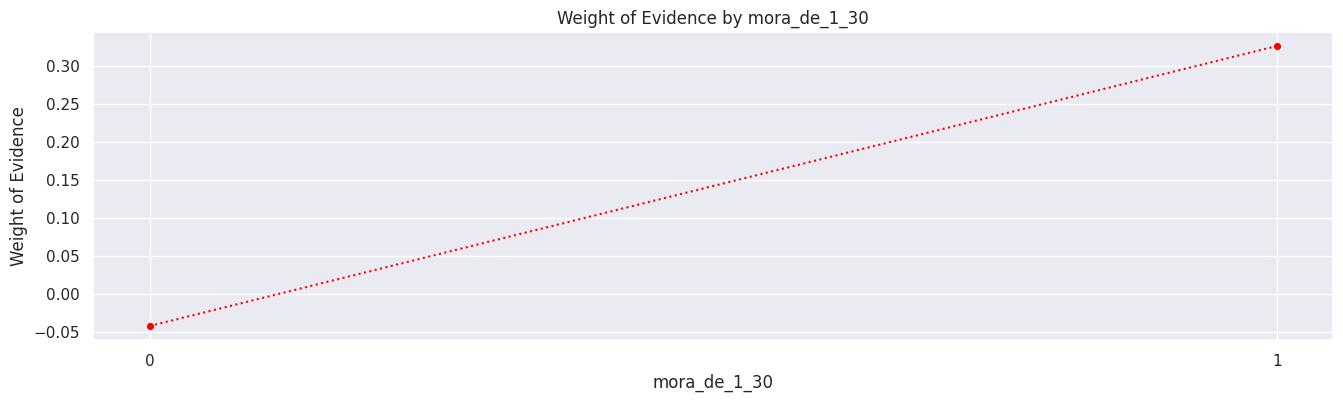

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'mora_de_1_30', inputs_target))

Este atributo tiene un poder predictivo muy débil: no será considerado.

##### regional

In [ ]:
woe_discrete(inputs_prepr, 'regional', inputs_target)

,regional,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,DC,2640,1872,768,0.429129,0.507266,0.403622,-0.228555,NaN,NaN,0.050745
1,OC,526,392,134,0.085501,0.088507,0.084519,-0.046106,0.036156,0.182449,0.050745
2,DN,1130,885,245,0.183680,0.161823,0.190815,0.164801,0.037939,0.210907,0.050745
3,DS,1856,1489,367,0.301691,0.242404,0.321044,0.280970,0.019077,0.116169,0.050745


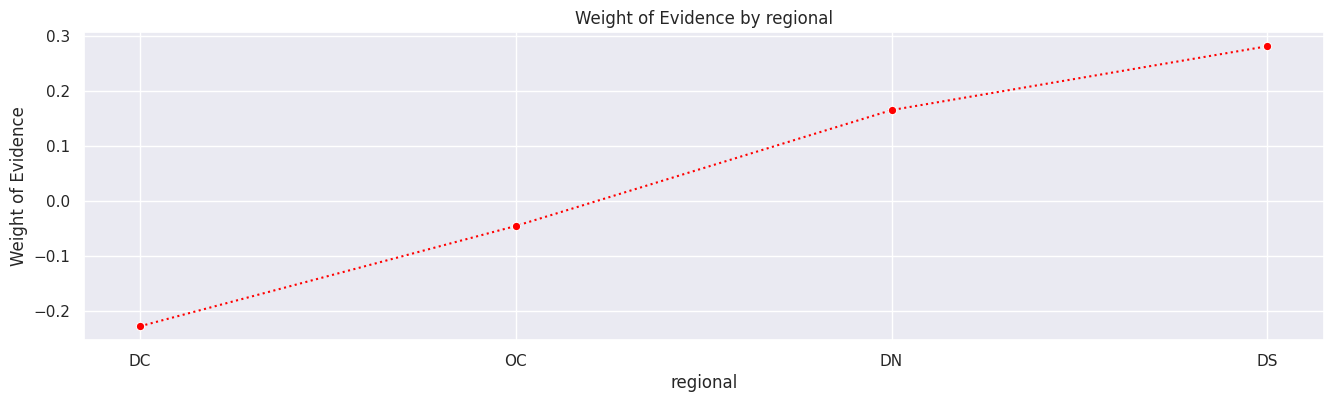

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'regional', inputs_target))

##### Unidad de negocio

In [ ]:
woe_discrete(inputs_prepr, 'unidad_negocio', inputs_target)

,unidad_negocio,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,OTRO NEGOCIO,245,108,137,0.039824,0.090489,0.023286,-1.357378,NaN,NaN,0.246251
1,GRN,2681,1847,834,0.435793,0.550859,0.398232,-0.324444,0.248106,1.032934,0.246251
2,ADM,1380,1141,239,0.224317,0.157860,0.246011,0.443669,0.137890,0.768112,0.246251
3,CIL,1846,1542,304,0.300065,0.200793,0.332471,0.504280,0.008508,0.060611,0.246251


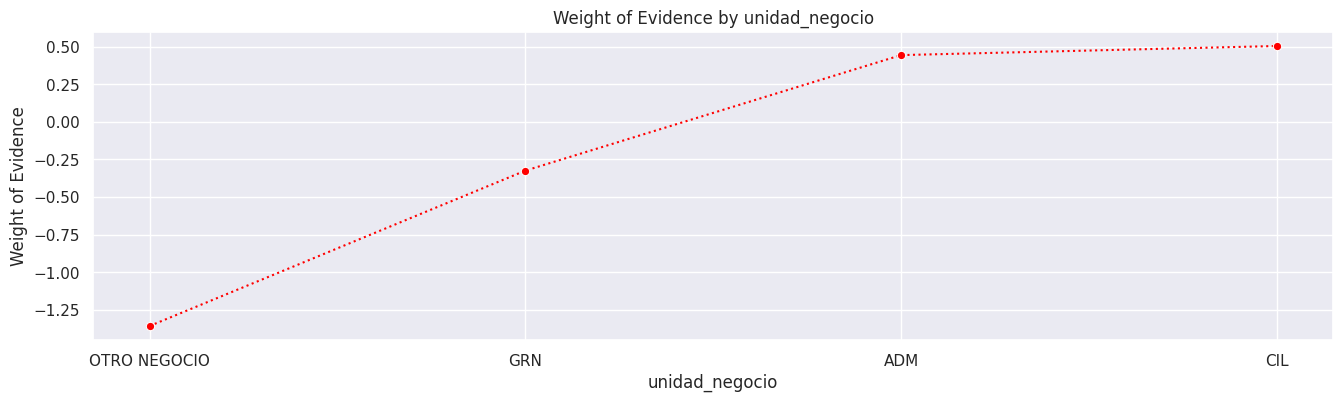

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'unidad_negocio', inputs_target))

In [ ]:
mapeo_un = {
    'ADM': 'ADM_CIL',
    'CIL': 'ADM_CIL'
}

# Aplicar el mapeo a la columna 'unidad_negocio'
inputs_prepr['unidad_negocio'] = inputs_prepr['unidad_negocio'].replace(mapeo_un)
inputs_prepr['unidad_negocio'].value_counts()

,count
unidad_negocio,
ADM_CIL,3226
GRN,2681
OTRO NEGOCIO,245


In [ ]:
woe_discrete(inputs_prepr, 'unidad_negocio', inputs_target)

,unidad_negocio,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,OTRO NEGOCIO,245,108,137,0.039824,0.090489,0.023286,-1.357378,NaN,NaN,0.245829
1,GRN,2681,1847,834,0.435793,0.550859,0.398232,-0.324444,0.248106,1.032934,0.245829
2,ADM_CIL,3226,2683,543,0.524382,0.358653,0.578482,0.478053,0.142758,0.802497,0.245829


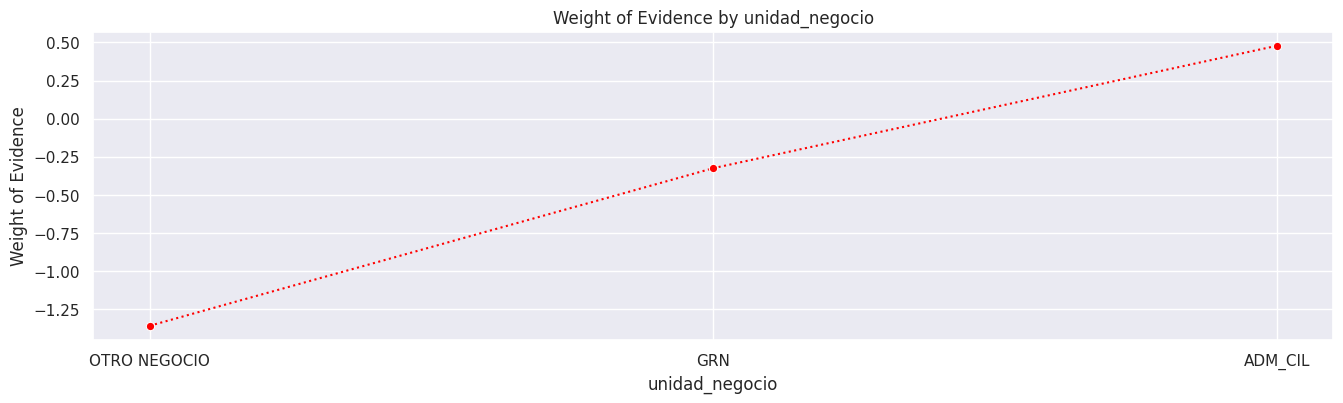

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'unidad_negocio', inputs_target))

In [ ]:
inputs_prepr['unidad_negocio:ADM_CIL'] = sum([inputs_prepr['unidad_negocio:ADM'], inputs_prepr['unidad_negocio:CIL']])

##### condicion pago

In [ ]:
woe_discrete(inputs_prepr, 'condicion_pago', inputs_target)

,condicion_pago,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,30D,1656,1191,465,0.269181,0.307133,0.256792,-0.179017,NaN,NaN,0.127358
1,CTD,2882,2080,802,0.468466,0.529723,0.448469,-0.166514,0.002518,0.012503,0.127358
2,15D,264,206,58,0.042913,0.038309,0.044416,0.147905,0.058582,0.314419,0.127358
3,OTRA CONDICION,555,460,95,0.090215,0.062748,0.099181,0.457822,0.048526,0.309916,0.127358
4,60D,246,206,40,0.039987,0.026420,0.044416,0.519469,0.008570,0.061647,0.127358
5,08D,549,495,54,0.089239,0.035667,0.106727,1.096046,0.064241,0.576577,0.127358


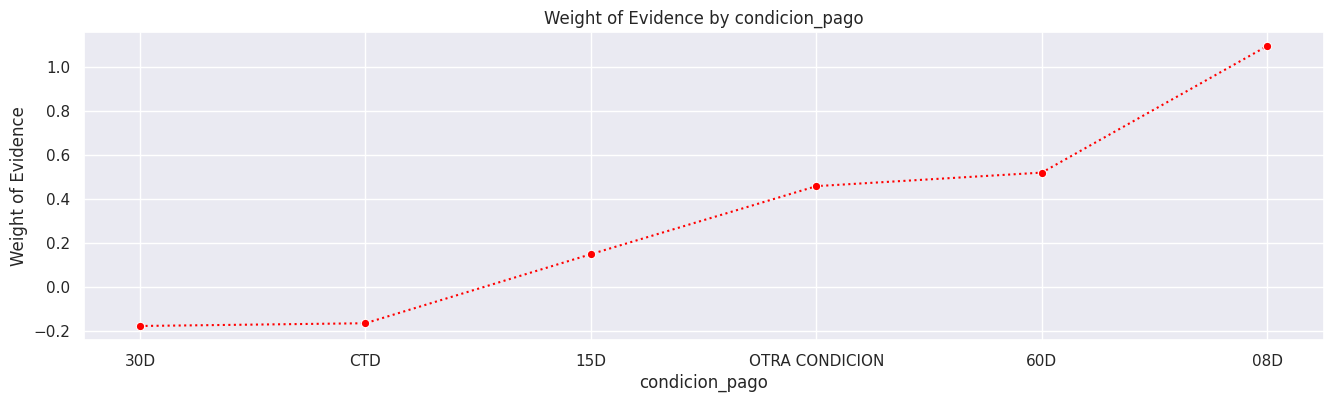

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'condicion_pago', inputs_target))

In [ ]:
mapeo_cp = {
    '30D': '30D o CTD',
    'CTD': '30D o CTD',
    'OTRA CONDICION': 'OTRO',
    '60D': 'OTRO'
}

# Aplicar el mapeo a la columna 'centro_operacion'
inputs_prepr['condicion_pago'] = inputs_prepr['condicion_pago'].replace(mapeo_cp)
inputs_prepr['condicion_pago'].value_counts()

,count
condicion_pago,
30D o CTD,4538
OTRO,801
08D,549
15D,264


In [ ]:
woe_discrete(inputs_prepr, 'condicion_pago', inputs_target)

,condicion_pago,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,30D o CTD,4538,3271,1267,0.737646,0.836856,0.705261,-0.171084,NaN,NaN,0.127236
1,15D,264,206,58,0.042913,0.038309,0.044416,0.147905,0.059501,0.318989,0.127236
2,OTRO,801,666,135,0.130202,0.089168,0.143596,0.476487,0.051158,0.328582,0.127236
3,08D,549,495,54,0.089239,0.035667,0.106727,1.096046,0.070179,0.619559,0.127236


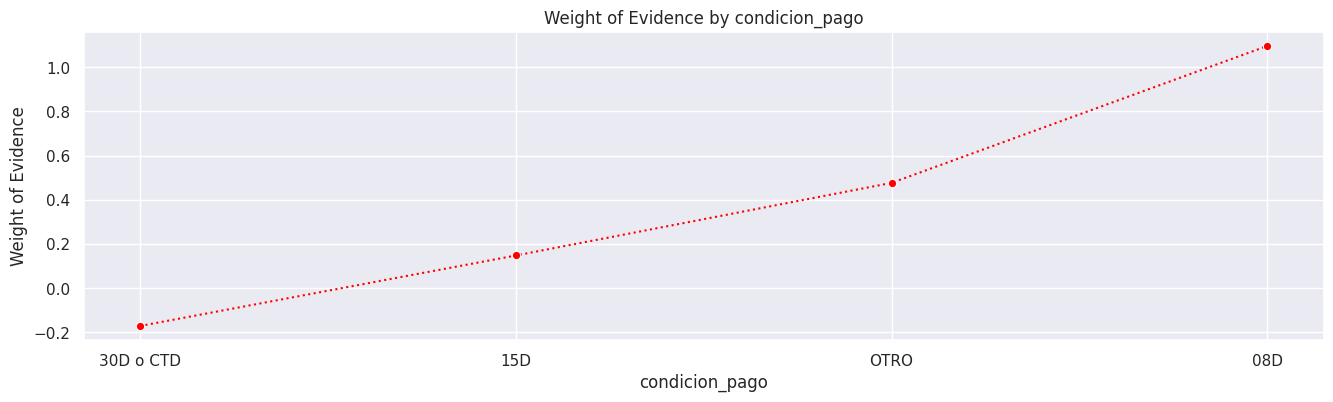

In [ ]:
plot_by_woe(woe_discrete(inputs_prepr, 'condicion_pago', inputs_target))

In [ ]:
inputs_prepr['condicion_pago:30D_CTD'] = sum([inputs_prepr['condicion_pago:30D'], inputs_prepr['condicion_pago:CTD']])
inputs_prepr['condicion_pago:OTRO'] = sum([inputs_prepr['condicion_pago:OTRA CONDICION'], inputs_prepr['condicion_pago:60D']])

#### Resultado

En resumen tenemos:

- centro de operación con 0.11 (mediano)
- mora de 30 a 60 con 0.05 (débil)
- mora de 60 a 90 con 0.04 (débil)
- mora mayor de 90 con 0.05 (débil)
- mora de 1 a 30 con 0.01 (muy débil)
- regional con 0.05 (débil)
- unidad de negocio con 0.24 (mediano)
- condición de pago con 0.12 (mediano)

#### Numéricas

In [ ]:
inputs_prepr[num_consider].nunique().sort_values()

,0
min_mora,489
max_mora,857
porcentaje_h_60_90,1030
porcentaje_h_mayor_90,1239
porcentaje_h_30_60,1799
antiguedad,1917
porcentaje_h_pago_a_tiempo,2960
porcentaje_h_1_30,3361


In [ ]:
# The function takes 3 arguments: a dataframe (X_train_prepr), a string (column name), and a dataframe (y_train_prepr).
# The function returns a dataframe as a result.
def woe_ordered_continuous(df, cat_variable_name, y_df):
    df = pd.concat([df[cat_variable_name], y_df], axis = 1)
    df = df.groupby(cat_variable_name, as_index=False).agg({df.columns[1]: ['count', 'sum']})
    df.columns = [cat_variable_name, 'n_obs', 'n_good']
    df['n_bad'] = df['n_obs'] - df['n_good']

    # WOE
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
   # df = df.sort_values(['WoE'])
   # df = df.reset_index(drop=True)

    # Difference between consequtive rows
    df['diff_prop_good'] = (df['n_good'] / df['n_obs']).diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()

    # IV
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

##### min_mora

In [ ]:
#acá los categoriza
inputs_prepr['min_mora_factor'] = np.where(inputs_prepr['min_mora']<0,'negativo',
                                              np.where(inputs_prepr['min_mora']>=0,'no negativo',0))

In [ ]:
woe_ordered_continuous(inputs_prepr, 'min_mora_factor', inputs_target)

,min_mora_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,negativo,3575,3115,460,0.581112,0.303831,0.671626,0.793230,NaN,NaN,0.568121
1,no negativo,2577,1523,1054,0.418888,0.696169,0.328374,-0.751438,0.280331,1.544668,0.568121


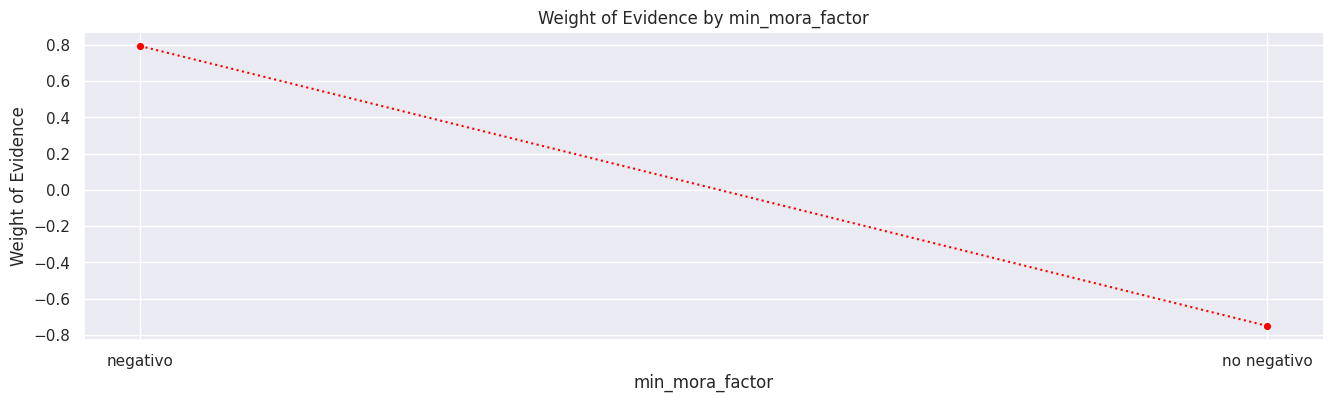

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'min_mora_factor', inputs_target))

In [ ]:
# agregamos las columnas a X_test_prepr

inputs_prepr['min_mora_factor'] = np.where(inputs_prepr['min_mora']<0,'negativo',
                                              np.where(inputs_prepr['min_mora']>=0,'no negativo',0))

Este atributo tiene poder predictivo sospechoso.


##### max mora

In [ ]:
inputs_prepr["max_mora_factor"] = pd.cut(inputs_prepr['max_mora'], 3)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'max_mora_factor', inputs_target[inputs_prepr.index])
#woe_ordered_continuous(inputs_prepr, 'max_mora_factor', inputs_target)

,max_mora_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-370.573, 1827.0]",6144,4634,1510,0.998700,0.997358,0.999138,0.001783,NaN,NaN,0.001995
1,"(1827.0, 4018.0]",6,3,3,0.000975,0.001982,0.000647,-1.119528,0.254232,1.121311,0.001995
2,"(4018.0, 6209.0]",2,1,1,0.000325,0.000661,0.000216,-1.119528,0.000000,0.000000,0.001995


No es muy descriptivo, y manualmente tampoco se ve una relación

In [ ]:
# coarse-classing
inputs_prepr['max_mora_factor'] = np.where(inputs_prepr['max_mora']<100,50,
                                              np.where(inputs_prepr['max_mora']<=300,200,
                                                    np.where(inputs_prepr['max_mora']>300,300,0)))

woe_ordered_continuous(inputs_prepr, 'max_mora_factor', inputs_target)

,max_mora_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,50,3802,3487,315,0.618010,0.208058,0.751833,1.284696,NaN,NaN,1.464413
1,200,1341,802,539,0.217978,0.356011,0.172919,-0.722135,0.319088,2.006831,1.464413
2,300,1009,349,660,0.164012,0.435931,0.075248,-1.756696,0.252174,1.034561,1.464413


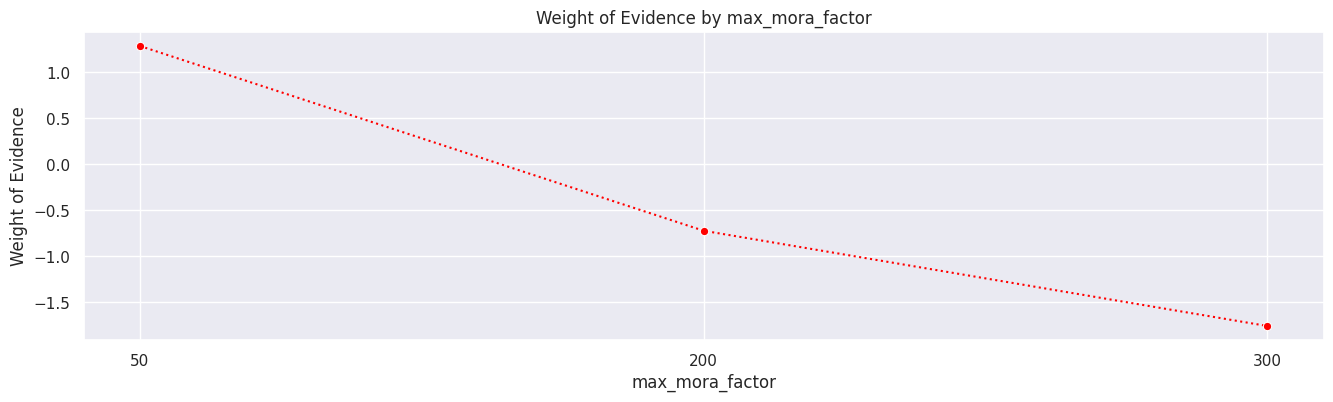

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'max_mora_factor', inputs_target))

Hay potencia de predicción sospechosa.

##### porcentaje_h_60_90

In [ ]:
# annual_inc
inputs_prepr['porcentaje_h_60_90_factor'] = pd.cut(inputs_prepr['porcentaje_h_60_90'], 5)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_60_90_factor', inputs_target)

,porcentaje_h_60_90_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.1, 20.0]",5866,4591,1275,0.953511,0.842140,0.989866,0.161624,NaN,NaN,0.460363
1,"(20.0, 40.0]",167,34,133,0.027146,0.087847,0.007331,-2.483517,0.579053,2.645140,0.460363
2,"(40.0, 60.0]",54,9,45,0.008778,0.029723,0.001940,-2.728966,0.036926,0.245449,0.460363
3,"(60.0, 80.0]",13,2,11,0.002113,0.007266,0.000431,-2.824276,0.012821,0.095310,0.460363
4,"(80.0, 100.0]",52,2,50,0.008453,0.033025,0.000431,-4.338404,0.115385,1.514128,0.460363


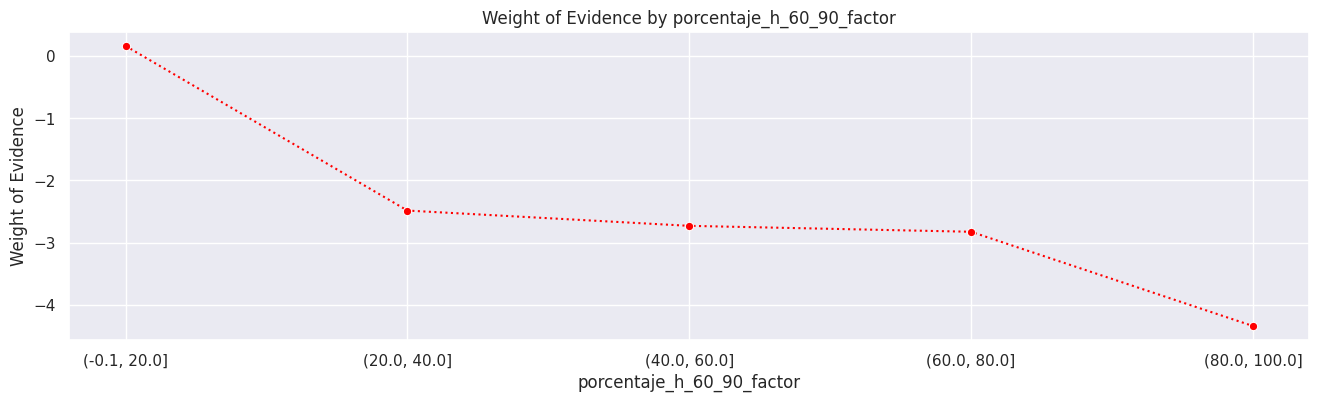

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'porcentaje_h_60_90_factor', inputs_target))

Acá vemos que el intervalo de 20 a 60 es muy similar, por lo tanto nos permite crear 3 grupos

In [ ]:
inputs_prepr['porcentaje_h_60_90_factor'] = np.where(inputs_prepr['porcentaje_h_60_90']<=20,'0 a 20',
                                            np.where(inputs_prepr['porcentaje_h_60_90']<=80,'20 a 80',
                                              np.where(inputs_prepr['porcentaje_h_60_90']>80,'80 a 100',0)))

woe_ordered_continuous(inputs_prepr, 'porcentaje_h_60_90_factor', inputs_target)

,porcentaje_h_60_90_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,0 a 20,5866,4591,1275,0.953511,0.842140,0.989866,0.161624,NaN,NaN,0.4594
1,20 a 80,234,45,189,0.038036,0.124835,0.009702,-2.554613,0.590338,2.716236,0.4594
2,80 a 100,52,2,50,0.008453,0.033025,0.000431,-4.338404,0.153846,1.783791,0.4594


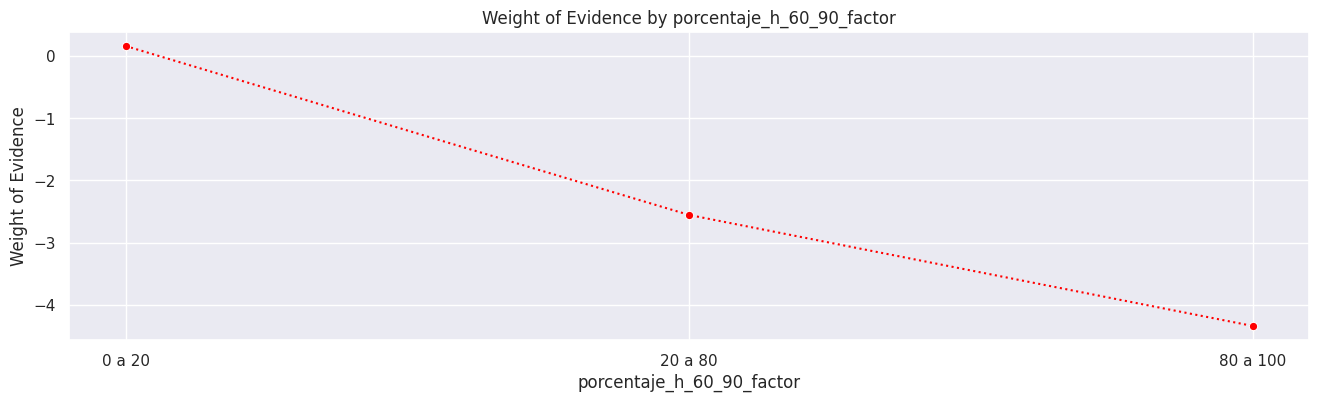

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'porcentaje_h_60_90_factor', inputs_target))

Presenta un nivel fuerte para la predicción.

In [ ]:
inputs_prepr['porcentaje_h_60_90: entre 0 y 20'] = np.where(inputs_prepr['porcentaje_h_60_90']<=20,1,0)
inputs_prepr['porcentaje_h_60_90: entre 20 y 80'] = np.where((inputs_prepr['porcentaje_h_60_90']>20)&(inputs_prepr['porcentaje_h_60_90']<=80),1,0)
inputs_prepr['porcentaje_h_60_90: entre 80 y 100'] = np.where(inputs_prepr['porcentaje_h_60_90']>80,1,0)

##### porcentaje_h_mayor_90

In [ ]:
# annual_inc
inputs_prepr['porcentaje_h_mayor_90_factor'] = pd.cut(inputs_prepr['porcentaje_h_mayor_90'], 10)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_mayor_90_factor', inputs_target)

,porcentaje_h_mayor_90_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.1, 10.0]",5167,4532,635,0.839889,0.419419,0.977145,0.845766,NaN,NaN,inf
1,"(10.0, 20.0]",243,74,169,0.039499,0.111625,0.015955,-1.945362,0.572578,2.791127,inf
2,"(20.0, 30.0]",125,20,105,0.020319,0.069353,0.004312,-2.777756,0.144527,0.832394,inf
3,"(30.0, 40.0]",124,4,120,0.020156,0.079260,0.000862,-4.520725,0.127742,1.742969,inf
4,"(40.0, 50.0]",90,3,87,0.014629,0.057464,0.000647,-4.486824,0.001075,0.033902,inf
5,"(50.0, 60.0]",62,2,60,0.010078,0.039630,0.000431,-4.520725,0.001075,0.033902,inf
6,"(60.0, 70.0]",29,1,28,0.004714,0.018494,0.000216,-4.451733,0.002225,0.068993,inf
7,"(70.0, 80.0]",46,0,46,0.007477,0.030383,0.000000,-inf,0.034483,inf,inf
8,"(80.0, 90.0]",18,0,18,0.002926,0.011889,0.000000,-inf,0.000000,NaN,inf
9,"(90.0, 100.0]",248,2,246,0.040312,0.162483,0.000431,-5.931712,0.008065,inf,inf


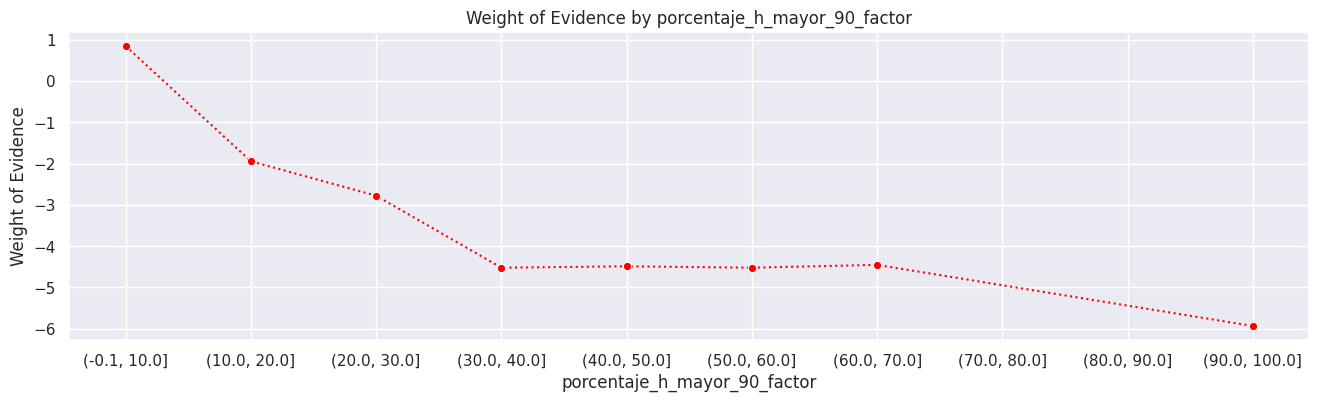

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'porcentaje_h_mayor_90_factor', inputs_target))

##### porcentaje_h_30_60

In [ ]:
# annual_inc
inputs_prepr['porcentaje_h_30_60_factor'] = pd.cut(inputs_prepr['porcentaje_h_30_60'], 3)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_30_60_factor', inputs_target)

,porcentaje_h_30_60_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.1, 33.333]",5690,4475,1215,0.924902,0.802510,0.964856,0.184234,NaN,NaN,0.386987
1,"(33.333, 66.667]",305,143,162,0.049577,0.107001,0.030832,-1.244280,0.317615,1.428514,0.386987
2,"(66.667, 100.0]",157,20,137,0.025520,0.090489,0.004312,-3.043777,0.341464,1.799497,0.386987


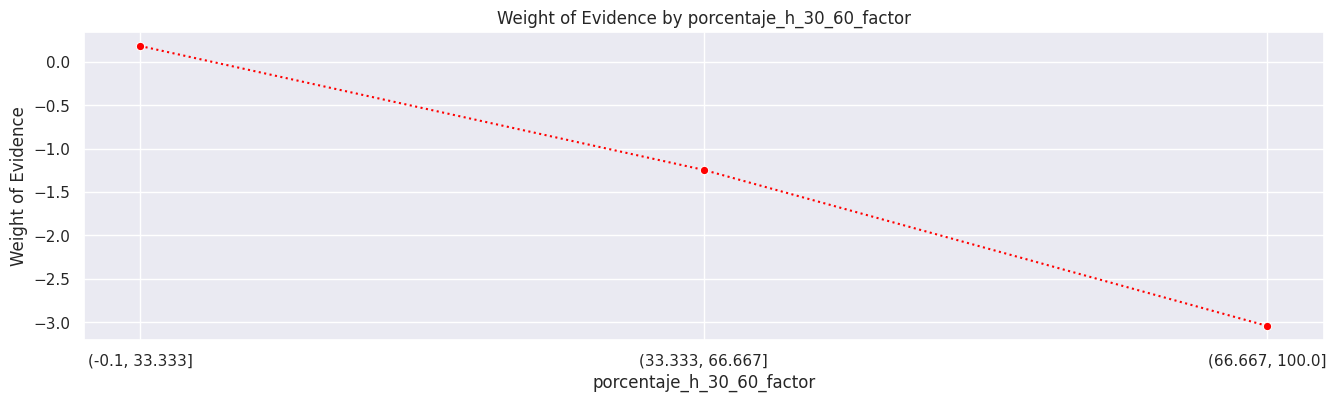

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'porcentaje_h_30_60_factor', inputs_target))

In [ ]:
inputs_prepr['porcentaje_h_30_60: entre 0 y 30'] = np.where(inputs_prepr['porcentaje_h_30_60']<=30,1,0)
inputs_prepr['porcentaje_h_30_60: entre 30 y 70'] = np.where((inputs_prepr['porcentaje_h_30_60']>30)&(inputs_prepr['porcentaje_h_30_60']<=70),1,0)
inputs_prepr['porcentaje_h_30_60: entre 70 y 100'] = np.where(inputs_prepr['porcentaje_h_30_60']>70,1,0)

##### antiguedad

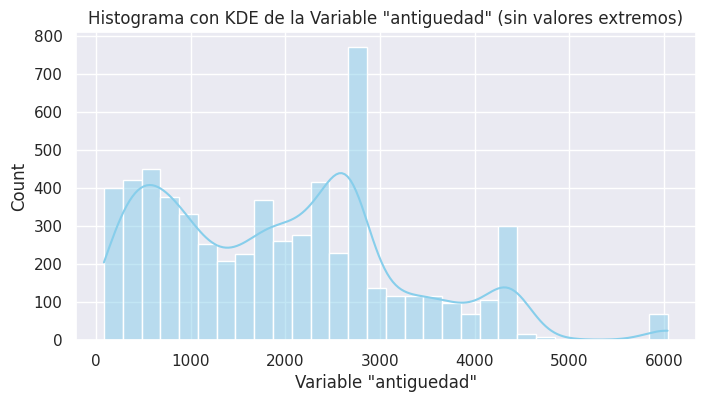

In [ ]:
# Definir el rango para los valores que deseas incluir en el histograma
# Fue necesario quitar valores atipicos porque hay valores extremos a izquierda
rango_deseado = (inputs_prepr['antiguedad'].quantile(0.01), inputs_prepr['antiguedad'].quantile(0.99))
datos_filtrados = inputs_prepr['antiguedad'].clip(lower=rango_deseado[0], upper=rango_deseado[1])

# Crear el histograma con la curva de distribución
plt.figure(figsize=(8, 4))
sns.histplot(datos_filtrados, bins=30, color='skyblue', kde=True)
plt.xlabel('Variable "antiguedad"')
plt.title('Histograma con KDE de la Variable "antiguedad" (sin valores extremos)')

# Mostrar el histograma con la curva de distribución
plt.show()

In [ ]:
# annual_inc
inputs_prepr['Antiguedad_factor'] = pd.cut(inputs_prepr['antiguedad'], 20)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'Antiguedad_factor', inputs_target)

,Antiguedad_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-13.235, 1222.75]",2182,1702,480,0.354681,0.317041,0.366969,0.146245,NaN,NaN,inf
1,"(1222.75, 2434.5]",1752,1204,548,0.284785,0.361955,0.259595,-0.332399,0.092804,0.478644,inf
2,"(2434.5, 3646.25]",1534,1145,389,0.249350,0.256935,0.246874,-0.039948,0.059200,0.292451,inf
3,"(3646.25, 4858.0]",605,518,87,0.098342,0.057464,0.111686,0.664539,0.109784,0.704487,inf
4,"(4858.0, 6069.75]",18,15,3,0.002926,0.001982,0.003234,0.489910,0.022865,0.174629,inf
5,"(6069.75, 7281.5]",11,9,2,0.001788,0.001321,0.001940,0.384549,0.015152,0.105361,inf
6,"(7281.5, 8493.25]",0,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,inf
7,"(8493.25, 9705.0]",0,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,inf
8,"(9705.0, 10916.75]",1,1,0,0.000163,0.000000,0.000216,inf,NaN,NaN,inf
9,"(10916.75, 12128.5]",5,5,0,0.000813,0.000000,0.001078,inf,0.000000,NaN,inf


In [ ]:
inputs_prepr['antiguedad'].describe()

,antiguedad
count,6152.000000
mean,2039.561443
std,1847.994933
min,11.000000
25%,823.000000
50%,1909.000000
75%,2684.000000
max,24246.000000


In [ ]:
inputs_prepr['antiguedad'].quantile(0.975)

4409.0

In [ ]:
inputs_prepr_temp = inputs_prepr.loc[inputs_prepr['antiguedad'] <= 5000, : ]

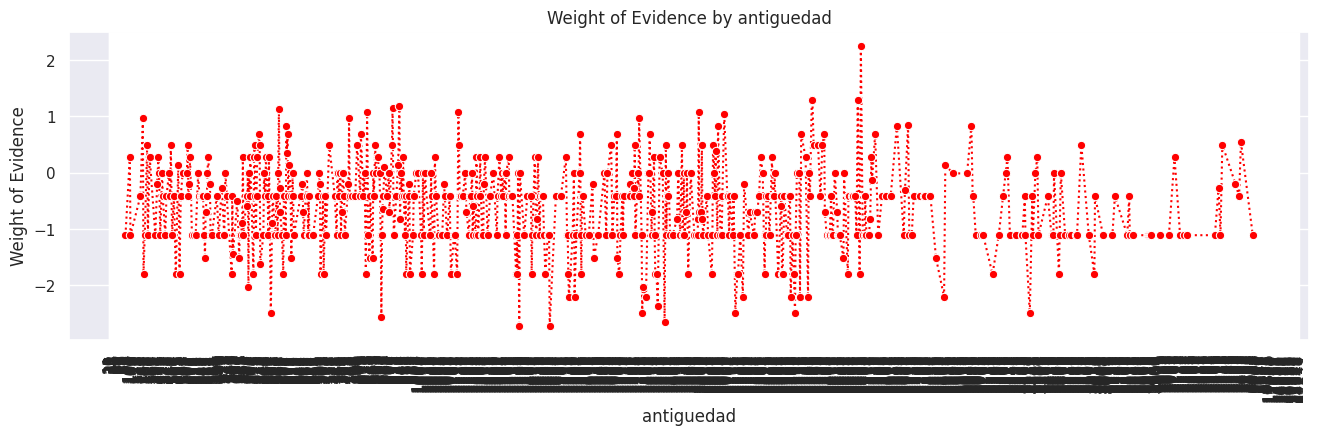

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'antiguedad', inputs_target[inputs_prepr_temp.index]),90)

5% de las observaciones serán considerados como valores muy altos

In [ ]:
inputs_prepr.shape, inputs_prepr_temp.shape

((6152, 67), (6075, 67))

In [ ]:
inputs_prepr_temp["Antiguedad_factor"] = pd.cut(inputs_prepr_temp['antiguedad'], 30)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr_temp, 'Antiguedad_factor', inputs_target[inputs_prepr_temp.index])

,Antiguedad_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(6.045, 176.167]",210,196,14,0.034568,0.009302,0.042888,1.528337,NaN,NaN,0.230912
1,"(176.167, 341.333]",303,262,41,0.049877,0.027243,0.057330,0.744052,0.068647,7.842849e-01,0.230912
2,"(341.333, 506.5]",381,282,99,0.062716,0.065781,0.061707,-0.063933,0.124529,8.079852e-01,0.230912
3,"(506.5, 671.667]",372,279,93,0.061235,0.061794,0.061050,-0.012108,0.009843,5.182507e-02,0.230912
4,"(671.667, 836.833]",300,230,70,0.049383,0.046512,0.050328,0.078864,0.016667,9.097178e-02,0.230912
5,"(836.833, 1002.0]",322,238,84,0.053004,0.055814,0.052079,-0.069266,0.027536,1.481302e-01,0.230912
6,"(1002.0, 1167.167]",216,159,57,0.035556,0.037874,0.034792,-0.084867,0.003019,1.560094e-02,0.230912
7,"(1167.167, 1332.333]",179,131,48,0.029465,0.031894,0.028665,-0.106724,0.004268,2.185662e-02,0.230912
8,"(1332.333, 1497.5]",184,124,60,0.030288,0.039867,0.027133,-0.384783,0.057931,2.780593e-01,0.230912
9,"(1497.5, 1662.667]",197,141,56,0.032428,0.037209,0.030853,-0.187312,0.041823,1.974712e-01,0.230912


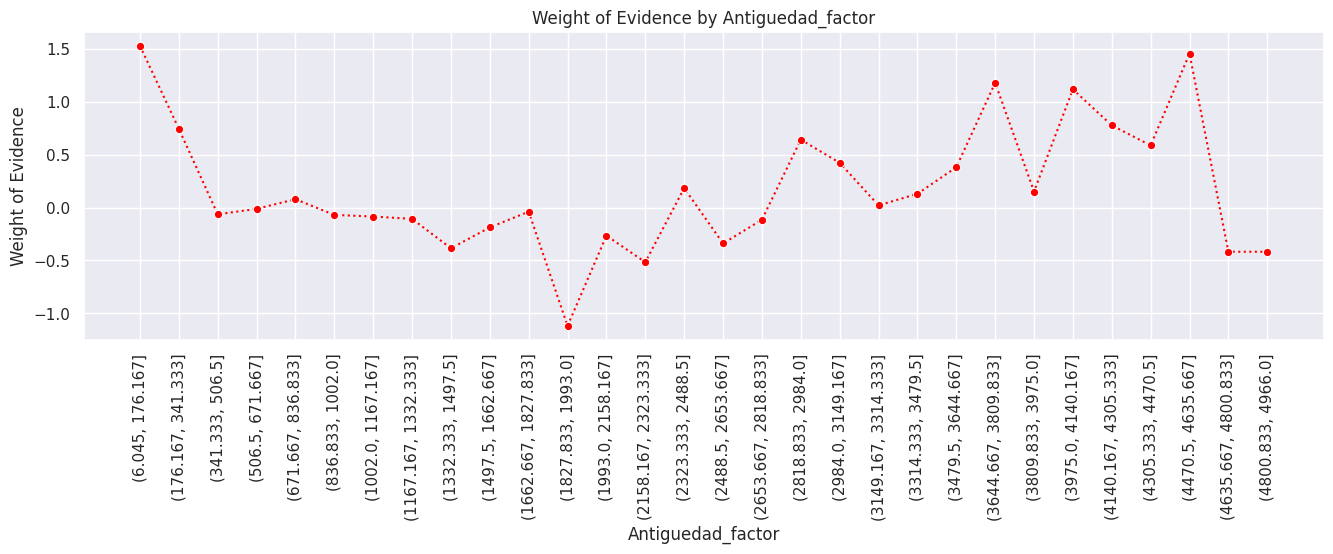

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr_temp, 'Antiguedad_factor', inputs_target[inputs_prepr_temp.index]),90)

In [ ]:
# coarse-classing
inputs_prepr['Antiguedad_factor'] = np.where(inputs_prepr['antiguedad']<=180, 'menor a 6 meses',
                                     np.where(inputs_prepr['antiguedad']<=360, 'entre 6 meses y 1 año',
                                      np.where(inputs_prepr['antiguedad']<=1080, 'entre 1 y 3 años',
                                        np.where(inputs_prepr['antiguedad']<=1800, 'entre 3 y 5 años',
                                         np.where(inputs_prepr['antiguedad']<=2160, 'entre 5 y 6 años',
                                          np.where(inputs_prepr['antiguedad']<=2880, 'entre 6 y 8 años',
                                           np.where(inputs_prepr['antiguedad']<=3600, 'entre 8 y 10 años',
                                            np.where(inputs_prepr['antiguedad']<=4320, 'entre 10 y 12 años',
                                               np.where(inputs_prepr['antiguedad']>4320, 'mayor a 12 años',0)))))))))

woe_ordered_continuous(inputs_prepr, 'Antiguedad_factor', inputs_target[inputs_prepr.index])

,Antiguedad_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,entre 1 y 3 años,1429,1068,361,0.232282,0.238441,0.230272,-0.034863,NaN,NaN,0.174471
1,entre 10 y 12 años,354,305,49,0.057542,0.032365,0.065761,0.708963,0.114206,0.743826,0.174471
2,entre 3 y 5 años,874,637,237,0.142068,0.156539,0.137344,-0.130819,0.132749,0.839782,0.174471
3,entre 5 y 6 años,580,349,231,0.094278,0.152576,0.075248,-0.706874,0.127109,0.576055,0.174471
4,entre 6 meses y 1 año,346,288,58,0.056242,0.038309,0.062096,0.482989,0.230646,1.189863,0.174471
5,entre 6 y 8 años,1557,1134,423,0.253088,0.279392,0.244502,-0.133394,0.104046,0.616383,0.174471
6,entre 8 y 10 años,441,352,89,0.071684,0.058785,0.075895,0.255467,0.069862,0.388861,0.174471
7,mayor a 12 años,356,304,52,0.057867,0.034346,0.065545,0.646256,0.055747,0.390789,0.174471
8,menor a 6 meses,215,201,14,0.034948,0.009247,0.043338,1.544719,0.080951,0.898464,0.174471


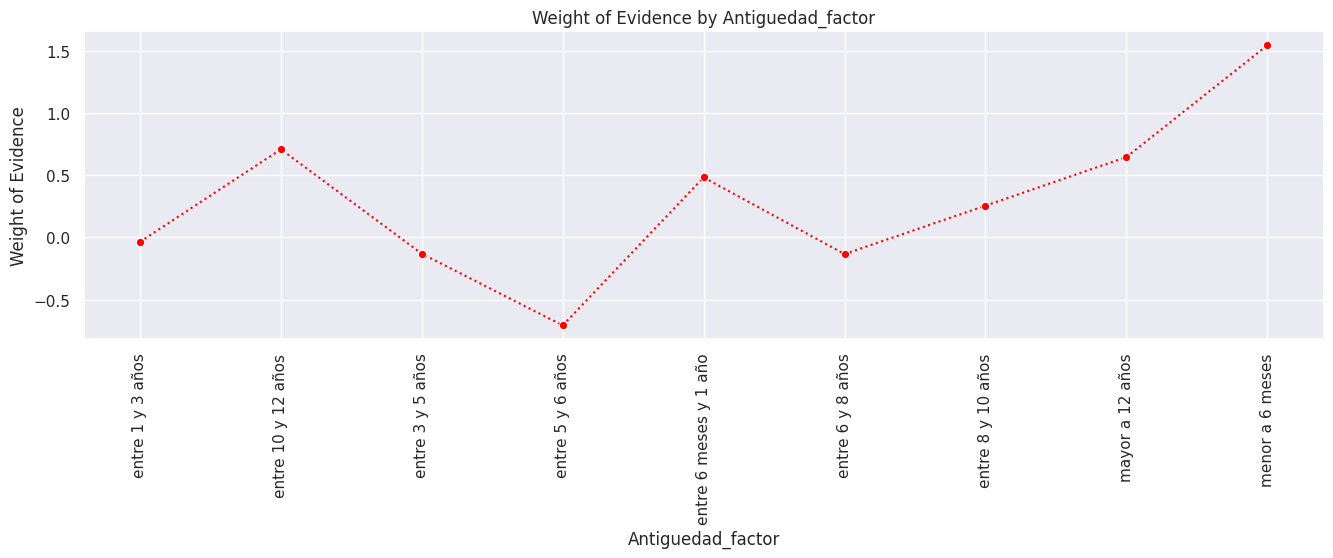

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'Antiguedad_factor', inputs_target[inputs_prepr.index]),90)

imputación de resultados en inputs_prep

In [ ]:
inputs_prepr['antiguedad: menor a 6 meses'] = np.where(inputs_prepr['antiguedad']<=180,1,0)
inputs_prepr['antiguedad: entre 6 meses y 1 año'] = np.where((inputs_prepr['antiguedad']>180)&(inputs_prepr['antiguedad']<=360),1,0)
inputs_prepr['antiguedad: entre 1 y 3 años'] = np.where((inputs_prepr['antiguedad']>360)&(inputs_prepr['antiguedad']<=1080),1,0)
inputs_prepr['antiguedad: entre 3 y 5 años'] = np.where((inputs_prepr['antiguedad']>1080)&(inputs_prepr['antiguedad']<=1800),1,0)
inputs_prepr['antiguedad: entre 5 y 6 años'] = np.where((inputs_prepr['antiguedad']>1800)&(inputs_prepr['antiguedad']<=2160),1,0)
inputs_prepr['antiguedad: entre 6 y 8 años'] = np.where((inputs_prepr['antiguedad']>2160)&(inputs_prepr['antiguedad']<=2880),1,0)
inputs_prepr['antiguedad: entre 8 y 10 años'] = np.where((inputs_prepr['antiguedad']>2880)&(inputs_prepr['antiguedad']<=3600),1,0)
inputs_prepr['antiguedad: entre 10 y 12 años'] = np.where((inputs_prepr['antiguedad']>3600)&(inputs_prepr['antiguedad']<=4320),1,0)
#inputs_prepr['Antiguedad:>2150 y <=2300'] = np.where((inputs_prepr['antiguedad']>2150)&(inputs_prepr['antiguedad']<=2300),1,0)
#inputs_prepr['Antiguedad:>2300 y <=2500'] = np.where((inputs_prepr['antiguedad']>2300)&(inputs_prepr['antiguedad']<=2500),1,0)
#inputs_prepr['Antiguedad:>2500 y <=2650'] = np.where((inputs_prepr['antiguedad']>2500)&(inputs_prepr['antiguedad']<=2650),1,0)
#inputs_prepr['Antiguedad:>2650 y <=2800'] = np.where((inputs_prepr['antiguedad']>2650)&(inputs_prepr['antiguedad']<=2800),1,0)
#inputs_prepr['Antiguedad:>2800 y <=3000'] = np.where((inputs_prepr['antiguedad']>2800)&(inputs_prepr['antiguedad']<=3000),1,0)
#inputs_prepr['Antiguedad:>3000 y <=3150'] = np.where((inputs_prepr['antiguedad']>3000)&(inputs_prepr['antiguedad']<=3150),1,0)
#inputs_prepr['Antiguedad:>3150 y <=3300'] = np.where((inputs_prepr['antiguedad']>3150)&(inputs_prepr['antiguedad']<=3300),1,0)
#inputs_prepr['Antiguedad:>3300 y <=3450'] = np.where((inputs_prepr['antiguedad']>3300)&(inputs_prepr['antiguedad']<=3450),1,0)
#inputs_prepr['Antiguedad:>3450 y <=3650'] = np.where((inputs_prepr['antiguedad']>3450)&(inputs_prepr['antiguedad']<=3650),1,0)
#inputs_prepr['Antiguedad:>3650 y <=3800'] = np.where((inputs_prepr['antiguedad']>3650)&(inputs_prepr['antiguedad']<=3800),1,0)
#inputs_prepr['Antiguedad:>3800 y <=4000'] = np.where((inputs_prepr['antiguedad']>3800)&(inputs_prepr['antiguedad']<=4000),1,0)
#inputs_prepr['Antiguedad:>4000 y <=4150'] = np.where((inputs_prepr['antiguedad']>4000)&(inputs_prepr['antiguedad']<=4150),1,0)
#inputs_prepr['Antiguedad:>4150 y <=4300'] = np.where((inputs_prepr['antiguedad']>4150)&(inputs_prepr['antiguedad']<=4300),1,0)
#inputs_prepr['Antiguedad:>4300 y <=4450'] = np.where((inputs_prepr['antiguedad']>4300)&(inputs_prepr['antiguedad']<=4450),1,0)
#inputs_prepr['Antiguedad:>4450 y <=4600'] = np.where((inputs_prepr['antiguedad']>4450)&(inputs_prepr['antiguedad']<=4600),1,0)
#inputs_prepr['Antiguedad:>4600 y <=4800'] = np.where((inputs_prepr['antiguedad']>4600)&(inputs_prepr['antiguedad']<=4800),1,0)
inputs_prepr['antiguedad: mayor a 12 años'] = np.where(inputs_prepr['antiguedad']>4320,1,0)

In [ ]:
inputs_prepr.sample(5)

,porcentaje_h_mayor_90,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30,mora_de_30_60:0,mora_de_30_60:1,mora_de_60_90:0,mora_de_60_90:1,mora_mayor_90:0,mora_mayor_90:1,regional:DC,regional:DN,regional:DS,regional:OC,unidad_negocio:ADM,unidad_negocio:CIL,unidad_negocio:GRN,unidad_negocio:OTRO NEGOCIO,condicion_pago:08D,condicion_pago:15D,condicion_pago:30D,condicion_pago:60D,condicion_pago:CTD,condicion_pago:OTRA CONDICION,centro_operacion:BELLO,centro_operacion:BUCARAMANGA,centro_operacion:CARTAGENA,centro_operacion:CHIQUINQUIRA,centro_operacion:CUCUTA,centro_operacion:MANIZALES,centro_operacion:OFICINA CENTRAL,centro_operacion:OTRO CENTRO,centro_operacion:PITALITO,centro_operacion:SIBERIA,centro_operacion:VILLANUEVA,centro_operacion:YUMBO,mora_de_1_30:0,mora_de_1_30:1,centro_operacion:VILLANUEVA_YUMBO_BELLO,centro_operacion:CARTAGENA_BUCARAMANGA,unidad_negocio:ADM_CIL,condicion_pago:30D_CTD,condicion_pago:OTRO,min_mora_factor,max_mora_factor,porcentaje_h_60_90_factor,porcentaje_h_60_90: entre 0 y 20,porcentaje_h_60_90: entre 20 y 80,porcentaje_h_60_90: entre 80 y 100,porcentaje_h_mayor_90_factor,porcentaje_h_30_60_factor,porcentaje_h_30_60: entre 0 y 30,porcentaje_h_30_60: entre 30 y 70,porcentaje_h_30_60: entre 70 y 100,Antiguedad_factor,antiguedad: menor a 6 meses,antiguedad: entre 6 meses y 1 año,antiguedad: entre 1 y 3 años,antiguedad: entre 3 y 5 años,antiguedad: entre 5 y 6 años,antiguedad: entre 6 y 8 años,antiguedad: entre 8 y 10 años,antiguedad: entre 10 y 12 años,antiguedad: mayor a 12 años
5852,0.0,43.0,0.00,39.83,3.94,56.21,-29.0,469,0,0,0,DC,GRN,30D o CTD,CARTAGENA_BUCARAMANGA,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 1 y 3 años,0,0,1,0,0,0,0,0,0
7087,0.0,0.0,0.00,100.00,0.00,0.00,0.0,1507,0,0,0,OC,ADM_CIL,30D o CTD,VILLANUEVA_YUMBO_BELLO,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,1,0,no negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 3 y 5 años,0,0,0,1,0,0,0,0,0
1892,0.0,73.0,0.00,0.00,30.05,69.94,0.0,1571,0,0,0,DS,ADM_CIL,30D o CTD,VILLANUEVA_YUMBO_BELLO,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,1,0,no negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",0,1,0,entre 3 y 5 años,0,0,0,1,0,0,0,0,0
4650,0.0,86.0,4.71,44.59,0.00,50.69,-13.0,1017,0,0,1,DC,GRN,15D,SIBERIA,0,1,0,1,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 1 y 3 años,0,0,1,0,0,0,0,0,0
4975,0.0,14.0,0.00,0.00,0.00,100.00,13.0,417,0,0,0,DC,ADM_CIL,OTRO,SIBERIA,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,no negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 1 y 3 años,0,0,1,0,0,0,0,0,0


##### porcentaje_h_pago_a_tiempo

In [ ]:
# annual_inc
inputs_prepr['porcentaje_h_pago_a_tiempo_factor'] = pd.cut(inputs_prepr['porcentaje_h_pago_a_tiempo'], 2)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_pago_a_tiempo_factor', inputs_target)

,porcentaje_h_pago_a_tiempo_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.1, 50.0]",4422,3012,1410,0.718791,0.931308,0.649418,-0.360513,NaN,NaN,0.561094
1,"(50.0, 100.0]",1730,1626,104,0.281209,0.068692,0.350582,1.629959,0.258745,1.990473,0.561094


In [ ]:
inputs_prepr['porcentaje_h_pago_a_tiempo_factor'] = np.where(inputs_prepr['porcentaje_h_pago_a_tiempo']<25,1,
                                              np.where(inputs_prepr['porcentaje_h_pago_a_tiempo']>=25,2,0))

In [ ]:
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_pago_a_tiempo_factor', inputs_target)

,porcentaje_h_pago_a_tiempo_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,1,3287,2078,1209,0.534298,0.798547,0.448038,-0.577916,NaN,NaN,0.555851
1,2,2865,2560,305,0.465702,0.201453,0.551962,1.007923,0.261355,1.585838,0.555851


Tiene una fuerza predictiva sospechosa

##### porcentaje_h_1_30  

In [ ]:
# annual_inc
inputs_prepr['porcentaje_h_1_30_factor'] = pd.cut(inputs_prepr['porcentaje_h_1_30'], 10)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
woe_ordered_continuous(inputs_prepr, 'porcentaje_h_1_30_factor', inputs_target)

,porcentaje_h_1_30_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.1, 10.0]",1789,1100,689,0.290800,0.455086,0.237171,-0.651704,NaN,NaN,0.475177
1,"(10.0, 20.0]",388,266,122,0.063069,0.080581,0.057352,-0.340053,0.070698,0.311651,0.475177
2,"(20.0, 30.0]",428,287,141,0.069571,0.093131,0.061880,-0.408806,0.015006,0.068753,0.475177
3,"(30.0, 40.0]",426,303,123,0.069246,0.081242,0.065330,-0.217980,0.040707,0.190826,0.475177
4,"(40.0, 50.0]",551,416,135,0.089564,0.089168,0.089694,0.005882,0.043723,0.223862,0.475177
5,"(50.0, 60.0]",430,355,75,0.069896,0.049538,0.076542,0.435102,0.070590,0.429219,0.475177
6,"(60.0, 70.0]",395,324,71,0.064207,0.046896,0.069858,0.398536,0.005328,0.036566,0.475177
7,"(70.0, 80.0]",413,371,42,0.067133,0.027741,0.079991,1.059004,0.078052,0.660469,0.475177
8,"(80.0, 90.0]",411,367,44,0.066808,0.029062,0.079129,1.001644,0.005361,0.057360,0.475177
9,"(90.0, 100.0]",921,849,72,0.149707,0.047556,0.183053,1.347865,0.028880,0.346221,0.475177


Es un predictor fuerte. Vamos a categorizar entonces los grupos con esta división

In [ ]:
inputs_prepr['porcentaje_h_1_30_factor'] = np.where(inputs_prepr['porcentaje_h_1_30']<25,'Entre 0 y 25',
                                            np.where(inputs_prepr['porcentaje_h_1_30']<50,'Entre 25 y 50',
                                            np.where(inputs_prepr['porcentaje_h_1_30']<75,'Entre 50 y 75',
                                              np.where(inputs_prepr['porcentaje_h_1_30']>=75,'Entre 75 y 100',0))))

woe_ordered_continuous(inputs_prepr, 'porcentaje_h_1_30_factor', inputs_target)

,porcentaje_h_1_30_factor,n_obs,n_good,n_bad,prop_n_obs,prop_n_bad,prop_n_good,WoE,diff_prop_good,diff_WoE,IV
0,Entre 0 y 25,2377,1493,884,0.386378,0.583884,0.321906,-0.595442,NaN,NaN,0.463142
1,Entre 25 y 50,1152,832,320,0.187256,0.211361,0.179388,-0.164017,0.094120,0.431426,0.463142
2,Entre 50 y 75,1083,909,174,0.176040,0.114927,0.195990,0.533762,0.117113,0.697778,0.463142
3,Entre 75 y 100,1540,1404,136,0.250325,0.089828,0.302717,1.214898,0.072353,0.681136,0.463142


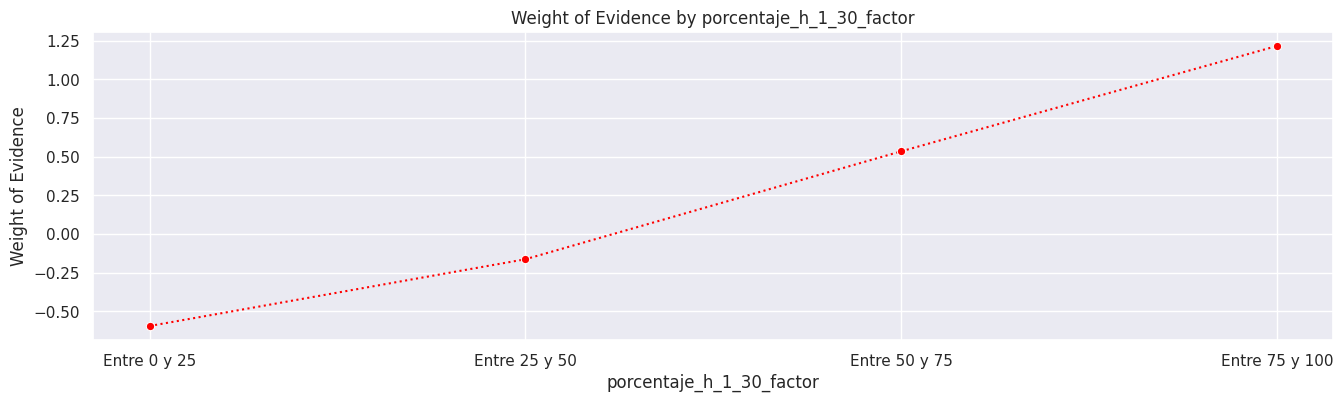

In [ ]:
plot_by_woe(woe_ordered_continuous(inputs_prepr, 'porcentaje_h_1_30_factor', inputs_target))

In [ ]:
inputs_prepr['porcentaje_h_1_30: entre 0 y 25'] = np.where(inputs_prepr['porcentaje_h_1_30']<=25,1,0)
inputs_prepr['porcentaje_h_1_30: entre 25 y 50'] = np.where((inputs_prepr['porcentaje_h_1_30']>25)&(inputs_prepr['porcentaje_h_1_30']<=50),1,0)
inputs_prepr['porcentaje_h_1_30: entre 50 y 75'] = np.where((inputs_prepr['porcentaje_h_1_30']>50)&(inputs_prepr['porcentaje_h_1_30']<=75),1,0)
inputs_prepr['porcentaje_h_1_30: entre 75 y 100'] = np.where(inputs_prepr['porcentaje_h_1_30']>75,1,0)

**Resumen:**

|Variable	| Tipo	| IV |	Menor WoE |
|--------|-------|----|--------|
|mora_de_30_60 |	Categorica |	0.05 |	1
|mora_de_60_90 |	Categorica |	0.05 |	1
|mora_mayor_90 |	Categorica |	0.06 |	1
|mora_de_1_30 |	Categorica |	0.01 |	0
|regional |	Categorica |	0.05 |	DC
|unidad_negocio	| Categorica |	0.25 |	OTRO NEGOCIO
|condicion_pago |	Categorica |	0.13 |	30 o CTD
|centro_operacion	| Categorica	| 0.11 |	SIBERIA
|min_mora |	Numerica |	0.57	| no negativo
|max_mora |	Numerica |	1.46	| 300
|porcentaje_h_60_90 |	Numerica |	0.46 |	80 a 100
|porcentaje_h_mayor_90 |	Numerica |	1.52	| (50,100]
|porcentaje_h_30_60 |	Numerica |	0.39 |	entre 70 y 100
|antiguedad |	Numerica |	0.22 | 	entre 3 y 5 años
|porcentaje_h_pago_a_tiempo |	Numerica |	0.56	| 0
|porcentaje_h_1_30 |	Numerica |	0.46	| Entre 0 y 25


## Guardar resultados

In [ ]:
inputs_prepr.sample(5)

,porcentaje_h_mayor_90,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30,mora_de_30_60:0,mora_de_30_60:1,mora_de_60_90:0,mora_de_60_90:1,mora_mayor_90:0,mora_mayor_90:1,regional:DC,regional:DN,regional:DS,regional:OC,unidad_negocio:ADM,unidad_negocio:CIL,unidad_negocio:GRN,unidad_negocio:OTRO NEGOCIO,condicion_pago:08D,condicion_pago:15D,condicion_pago:30D,condicion_pago:60D,condicion_pago:CTD,condicion_pago:OTRA CONDICION,centro_operacion:BELLO,centro_operacion:BUCARAMANGA,centro_operacion:CARTAGENA,centro_operacion:CHIQUINQUIRA,centro_operacion:CUCUTA,centro_operacion:MANIZALES,centro_operacion:OFICINA CENTRAL,centro_operacion:OTRO CENTRO,centro_operacion:PITALITO,centro_operacion:SIBERIA,centro_operacion:VILLANUEVA,centro_operacion:YUMBO,mora_de_1_30:0,mora_de_1_30:1,centro_operacion:VILLANUEVA_YUMBO_BELLO,centro_operacion:CARTAGENA_BUCARAMANGA,unidad_negocio:ADM_CIL,condicion_pago:30D_CTD,condicion_pago:OTRO,min_mora_factor,max_mora_factor,porcentaje_h_60_90_factor,porcentaje_h_60_90: entre 0 y 20,porcentaje_h_60_90: entre 20 y 80,porcentaje_h_60_90: entre 80 y 100,porcentaje_h_mayor_90_factor,porcentaje_h_30_60_factor,porcentaje_h_30_60: entre 0 y 30,porcentaje_h_30_60: entre 30 y 70,porcentaje_h_30_60: entre 70 y 100,Antiguedad_factor,antiguedad: menor a 6 meses,antiguedad: entre 6 meses y 1 año,antiguedad: entre 1 y 3 años,antiguedad: entre 3 y 5 años,antiguedad: entre 5 y 6 años,antiguedad: entre 6 y 8 años,antiguedad: entre 8 y 10 años,antiguedad: entre 10 y 12 años,antiguedad: mayor a 12 años,porcentaje_h_pago_a_tiempo_factor,porcentaje_h_1_30_factor,porcentaje_h_1_30: entre 0 y 25,porcentaje_h_1_30: entre 25 y 50,porcentaje_h_1_30: entre 50 y 75,porcentaje_h_1_30: entre 75 y 100
6479,0.00,43.0,0.00,10.94,4.28,84.76,-27.0,2489,0,0,0,DN,GRN,30D o CTD,CARTAGENA_BUCARAMANGA,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 6 y 8 años,0,0,0,0,0,1,0,0,0,1,Entre 75 y 100,0,0,0,1
1497,0.06,153.0,0.99,80.21,0.62,18.09,-9.0,1782,0,0,0,DS,ADM_CIL,08D,VILLANUEVA_YUMBO_BELLO,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,negativo,200,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 3 y 5 años,0,0,0,1,0,0,0,0,0,2,Entre 0 y 25,1,0,0,0
7198,0.00,11.0,0.00,50.00,0.00,50.00,0.0,476,0,0,0,DS,ADM_CIL,OTRO,MANIZALES,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,no negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 1 y 3 años,0,0,1,0,0,0,0,0,0,2,Entre 50 y 75,0,1,0,0
7451,0.58,96.0,9.94,76.54,3.65,9.26,-308.0,2356,0,0,0,DN,ADM_CIL,15D,CARTAGENA_BUCARAMANGA,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 6 y 8 años,0,0,0,0,0,1,0,0,0,2,Entre 0 y 25,1,0,0,0
212,0.00,67.0,0.00,0.00,0.00,0.00,-4.0,4409,0,0,0,DS,ADM_CIL,30D o CTD,VILLANUEVA_YUMBO_BELLO,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,1,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,mayor a 12 años,0,0,0,0,0,0,0,0,1,1,Entre 0 y 25,1,0,0,0


In [ ]:
inputs_prepr.shape

(6152, 82)

In [ ]:
X_train_prepr = inputs_prepr
y_train_prepr = inputs_target
#X_test_prepr = inputs_prepr
#y_test_prepr = inputs_target

In [ ]:
X_train_prepr.shape, X_test_prepr.shape

((6152, 82), (1538, 50))

In [ ]:
y_test_prepr.shape, X_test_prepr.shape

((1538,), (1538, 50))

### Exportación

Al final ejecutar estos



```
X_train_prepr.to_csv('X_train_prepr.csv')
y_train_prepr.to_csv('y_train_prepr.csv')
X_test_prepr.to_csv('X_test_prepr.csv')
y_test_prepr.to_csv('y_test_prepr.csv')
```







In [ ]:
## Ejecutar aca